# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 09     |  |
| :-------------|:-------------|
| Christoph Smit| 6494056 |
| Shannon Werleman| 6292933 |
| Casper Jansen| 6265200 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['ChristophSmit', 'ShannonWerleman','CasperJansen']

## Opdracht 1: Planning.

| Planning Groep: 09     |Tijdstip / Tijdspanne  |
|---|---|
| Kalibratie + Testmeting | 12:00 af |
| Eerste Iteratie | 12:30 af |
| Algoritme af en getest| 16:30 |
| Opruimen en feedback klaar| 17:00 |
| Pauze 1| 12:30-13:30 |
| Pauze 2| Tijdspanne |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
from scipy.optimize import curve_fit

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [09]
<img src="kalibratie.jpg" width="400">

0.03468600361233243 -0.28257771589955416


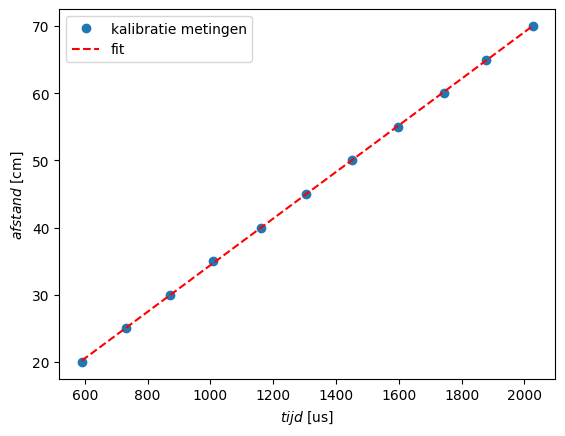

In [3]:
# verwerk hier jullie kalibratiemetingen
tijd = np.array([1180, 1460, 1743, 2016, 2320, 2610, 2903, 3195, 3490, 3752, 4052])/2
afstand = np.array([20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70])

def fit(x, a, b):
    return a * x + b

popt,pcov = curve_fit(fit, tijd, afstand)

a = popt[0]
b = popt[1]

xtest = np.linspace(np.min(tijd), np.max(tijd), 1000)
ytest = fit(xtest, a, b)


plt.plot(tijd, afstand, 'o', label='kalibratie metingen')
plt.plot(xtest, ytest, 'r--', label='fit')
plt.xlabel('$tijd$ [us]')
plt.ylabel('$afstand$ [cm]')
plt.legend()
print(a,b)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  30  41.64
1   0  30   0  20  41.12
2  40   0  30   0  40.16
3  30   0  20   0  39.78


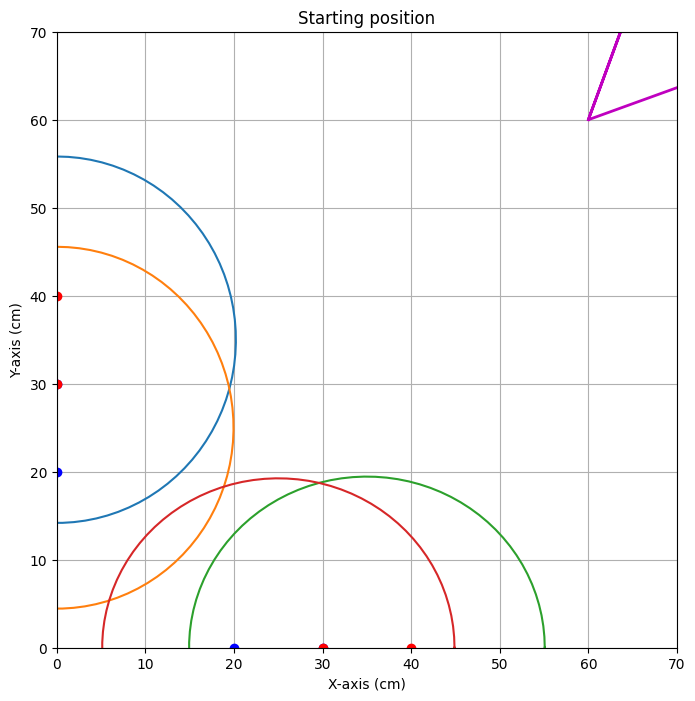


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.280


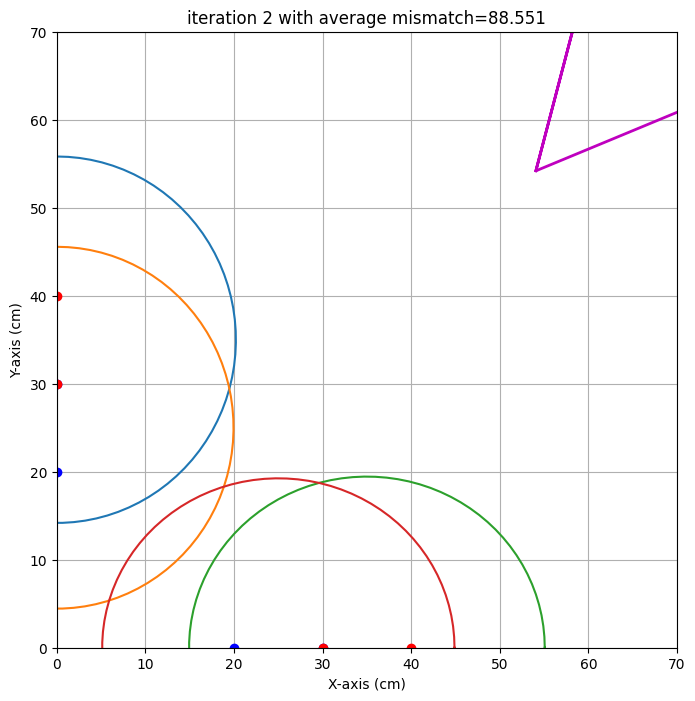

end iteration 2 with average mismatch=88.551


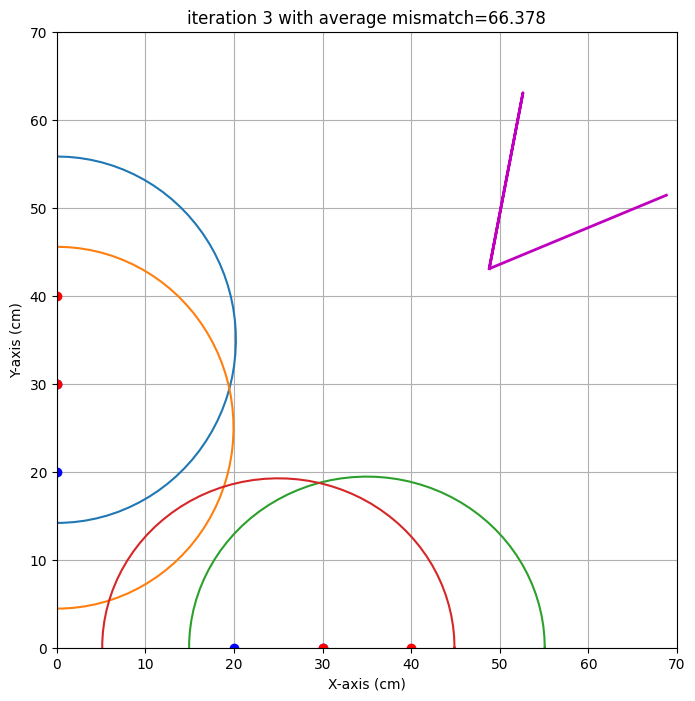

end iteration 3 with average mismatch=66.378


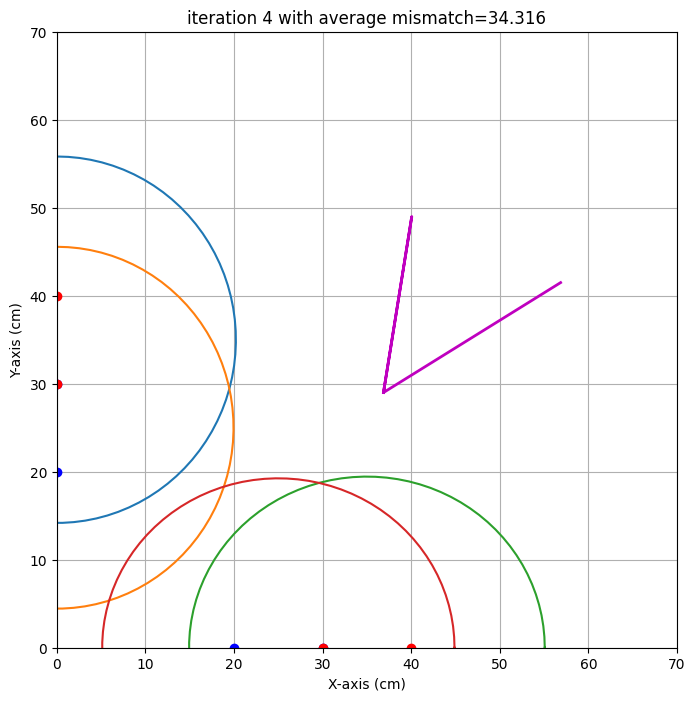

end iteration 4 with average mismatch=34.316


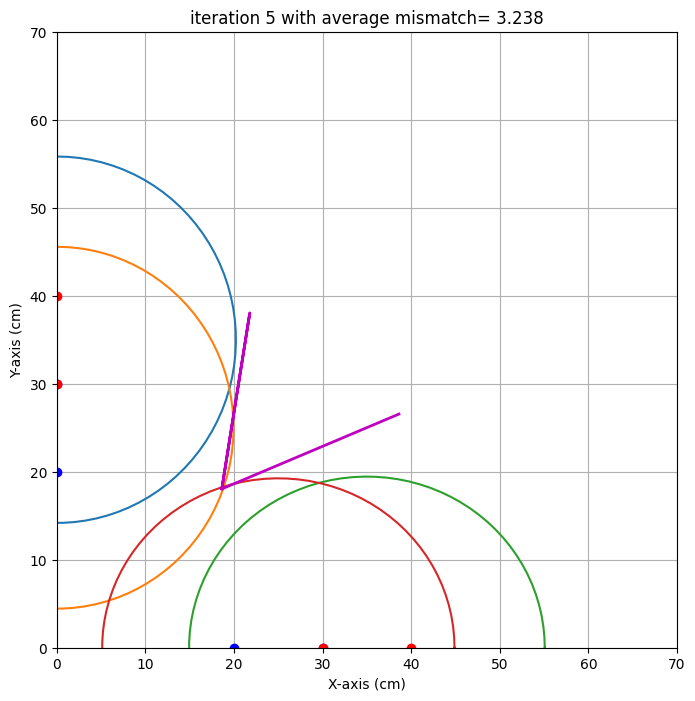

end iteration 5 with average mismatch= 3.238


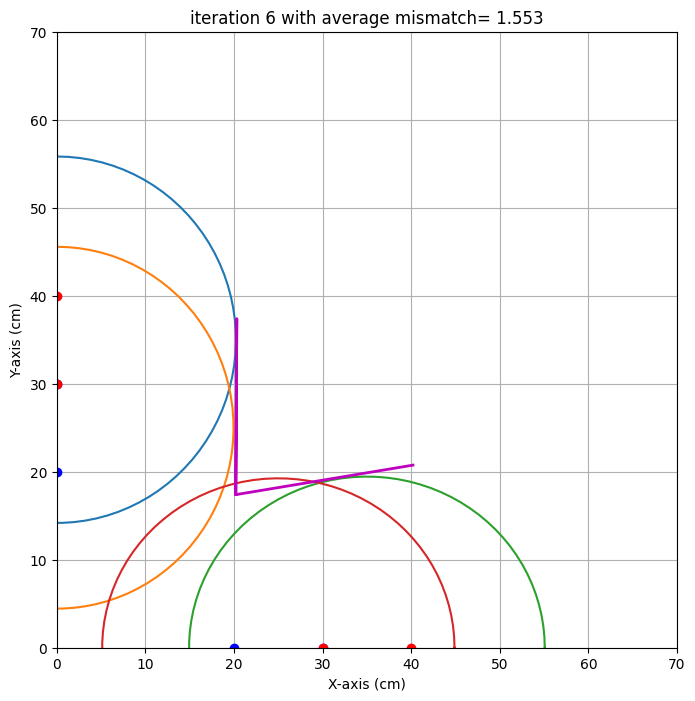

end iteration 6 with average mismatch= 1.553


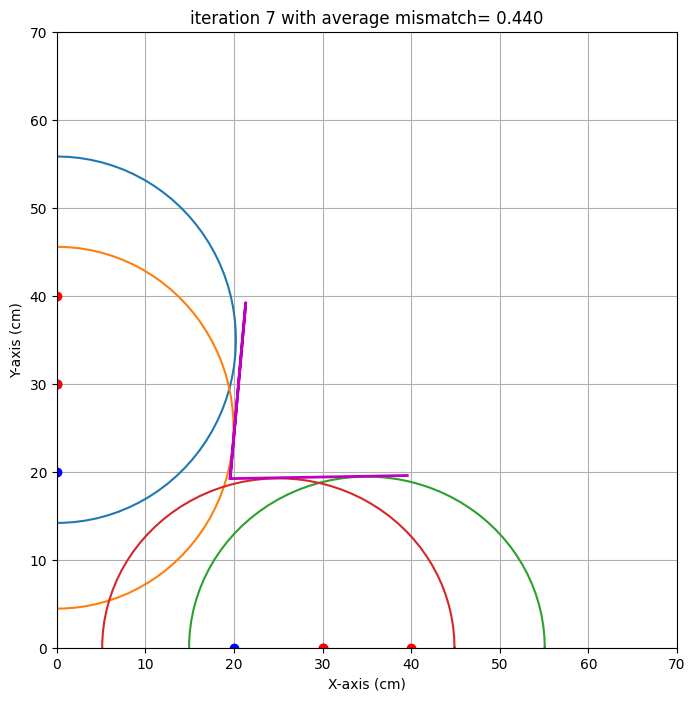

end iteration 7 with average mismatch= 0.440


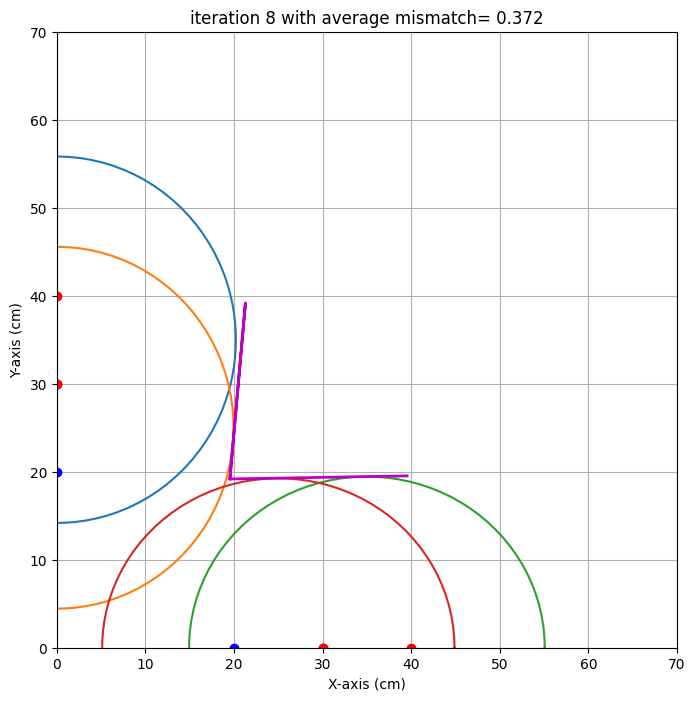

end iteration 8 with average mismatch= 0.372
end iteration 9 with average mismatch= 0.368
end iteration 10 with average mismatch= 0.367
end iteration 11 with average mismatch= 0.367
end iteration 12 with average mismatch= 0.367
end iteration 13 with average mismatch= 0.367
end iteration 14 with average mismatch= 0.367
end iteration 15 with average mismatch= 0.367


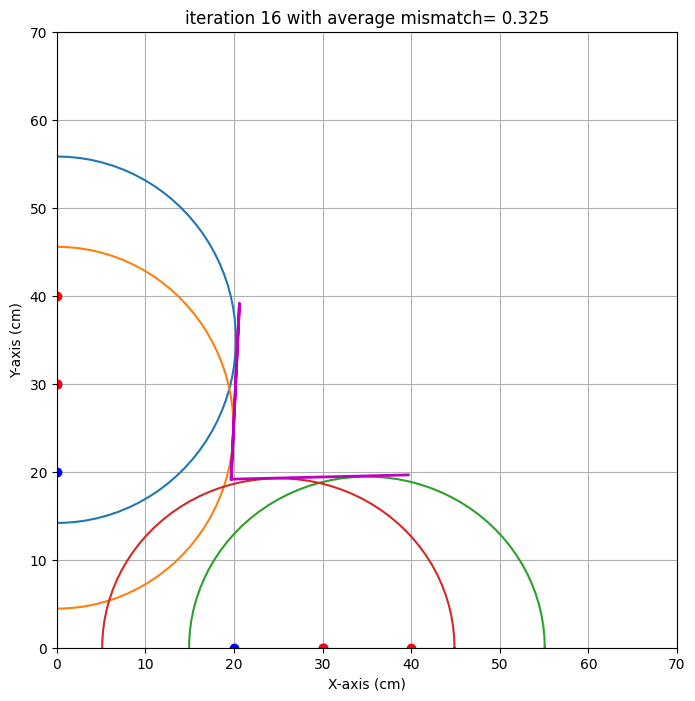

end iteration 16 with average mismatch= 0.325
end iteration 17 with average mismatch= 0.295
end iteration 18 with average mismatch= 0.295
end iteration 19 with average mismatch= 0.295
end iteration 20 with average mismatch= 0.295
end iteration 21 with average mismatch= 0.295
end iteration 22 with average mismatch= 0.295
end iteration 23 with average mismatch= 0.295
end iteration 24 with average mismatch= 0.295
end iteration 25 with average mismatch= 0.295
end iteration 26 with average mismatch= 0.295
end iteration 27 with average mismatch= 0.295
end iteration 28 with average mismatch= 0.295
end iteration 29 with average mismatch= 0.295
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.295
###############################################################################
end of iteration  30
Best alpha=   1.37 with uncertainty=   0.21
Best b

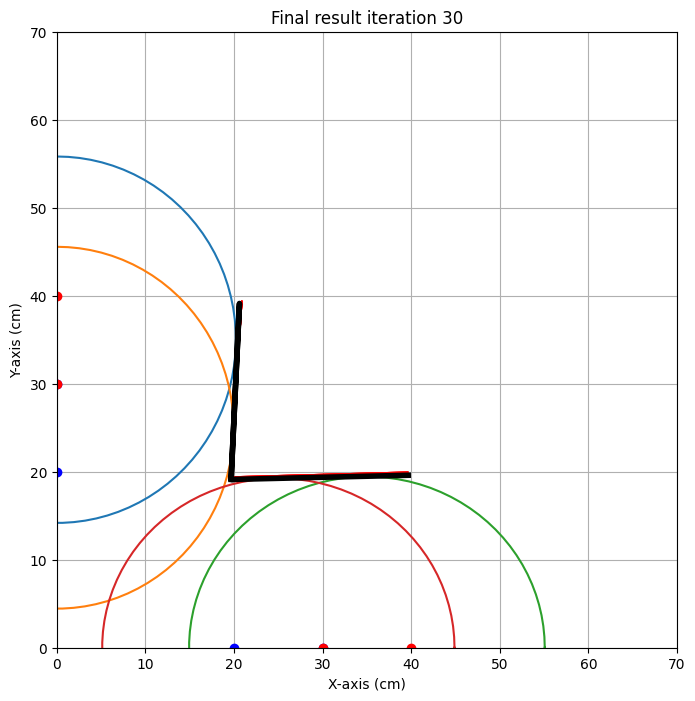

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.64],
    [0,30,0,20,41.12],
    #[0,10,0,20,130.0],
    [40,0,30,0,40.16],
    [30,0,20,0,39.78],
    #[10,0,20,0,120.0],
    #[10,0,0,10,129.34]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.7 cm met een standaardafwijking van 0.1 cm 
y0: 19.1 cm met een standaardafwijking van 0.3 cm 
alpha: 1.4 graden met een standaardafwijking van 0.2 graad 
beta: 2.7 graden met een standaardafwijking van 0.9 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Christoph]

<img src="algoritmechristoph.jpeg" width="400">

#### algoritme [Shannon]

<img src="Algoritme.jpeg" width="400">

#### algoritme [Casper]

<img src="algorcasper.jpeg" width="400">

## Opdracht 6: Test iteratie 0.

In [6]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':35.5,
           'y0':41.9,
           'alpha' : 7,
           'beta' : 0
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={ studentNames[1] :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,20,0,30,ongeldig],
    [0,70,0,60,70.23],
    [0,50,0,60,69.05],
    #[20,0,30,0,ongeldig],
    #[70,0,60,0,ongeldig],
    [40,0,50,0, 86.70],
    [45,0,55,0,88.31]
    ]),
       studentNames[0] : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,70,0,60,69.95],
    [0,65,0,55,69.39],
    [0,60,0,50,70.05],
    [0,55,0,45,69.95],
    [0,50,0,40,69.60],
    [0,45,0,35,73.50],
    # [0,40,0,30,ongeldig],
    [70,0,60,0,95.32],
    [65,0,55,0,92.57],
    [60,0,50,0,91.80],
    [55,0,45,0,89.83],
    [50,0,40,0,89.80],
    [45,0,35,0,92.98]
    #[40,0,30,0,ongeldig]
    ]),
       studentNames[2] : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
         [70,0,60,0,97.50],
         [0,49,0,59,70.3],
         [0,59,0,69,69.50],
         [0,39,0,49,69.85],
         [60,0,50,0,93.06]  
       ])
   
   }

## Opdracht 7: Evaluatie.

ChristophSmit
Running the imaging algorithm with the following data:
    xs  ys  xr  yr      R
0    0  70   0  60  69.95
1    0  65   0  55  69.39
2    0  60   0  50  70.05
3    0  55   0  45  69.95
4    0  50   0  40  69.60
5    0  45   0  35  73.50
6   70   0  60   0  95.32
7   65   0  55   0  92.57
8   60   0  50   0  91.80
9   55   0  45   0  89.83
10  50   0  40   0  89.80
11  45   0  35   0  92.98


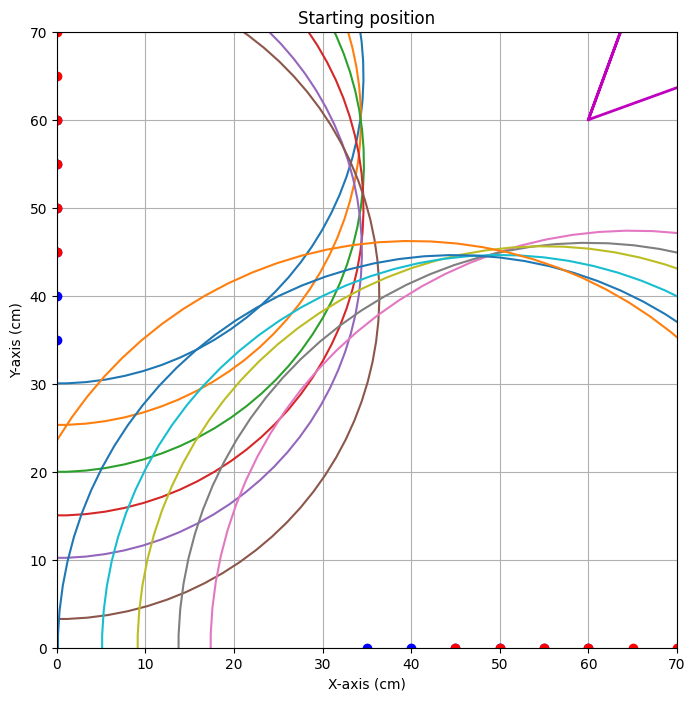


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.168


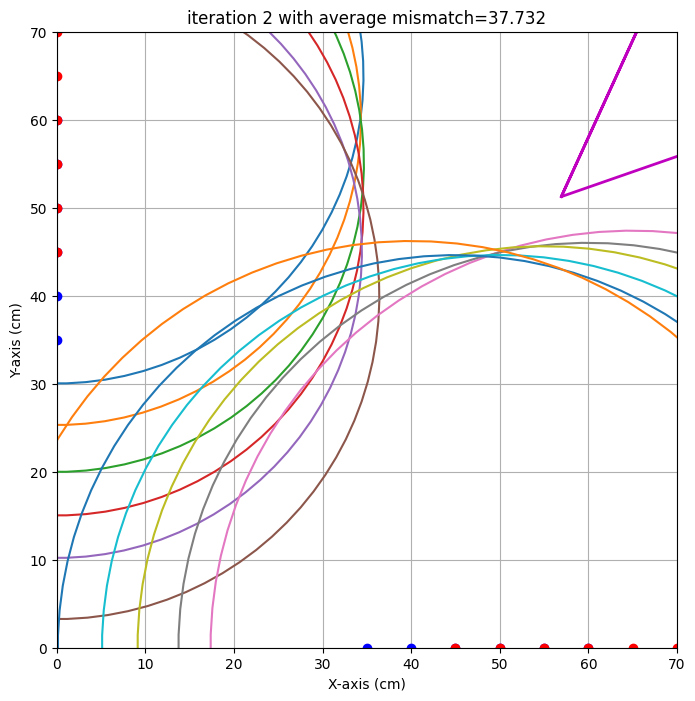

end iteration 2 with average mismatch=37.732


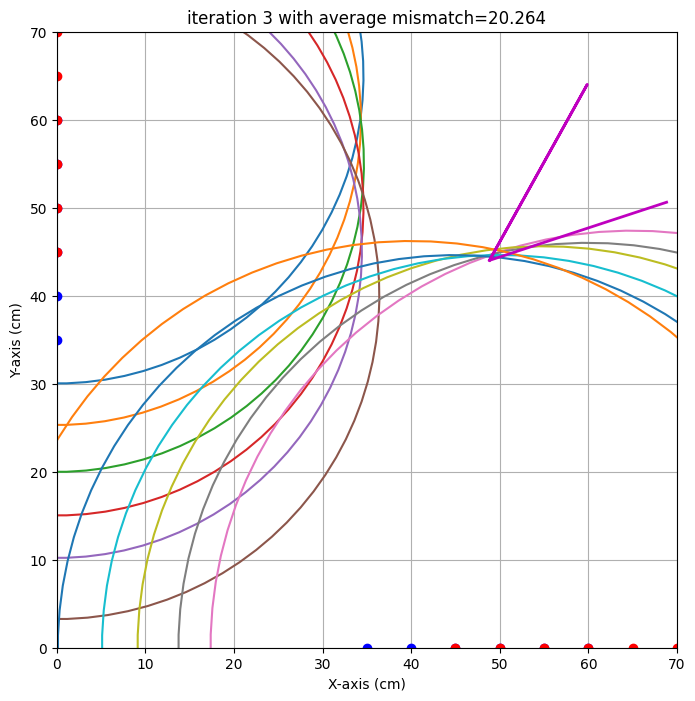

end iteration 3 with average mismatch=20.264


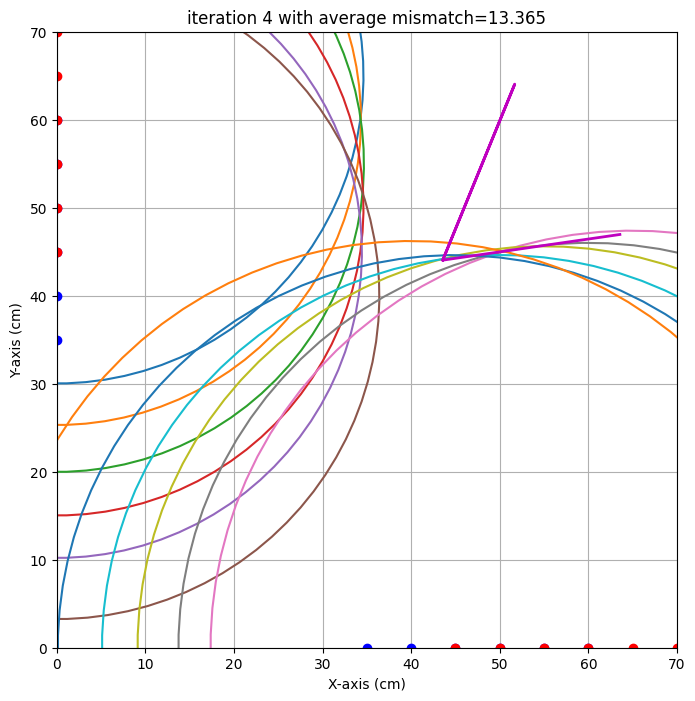

end iteration 4 with average mismatch=13.365


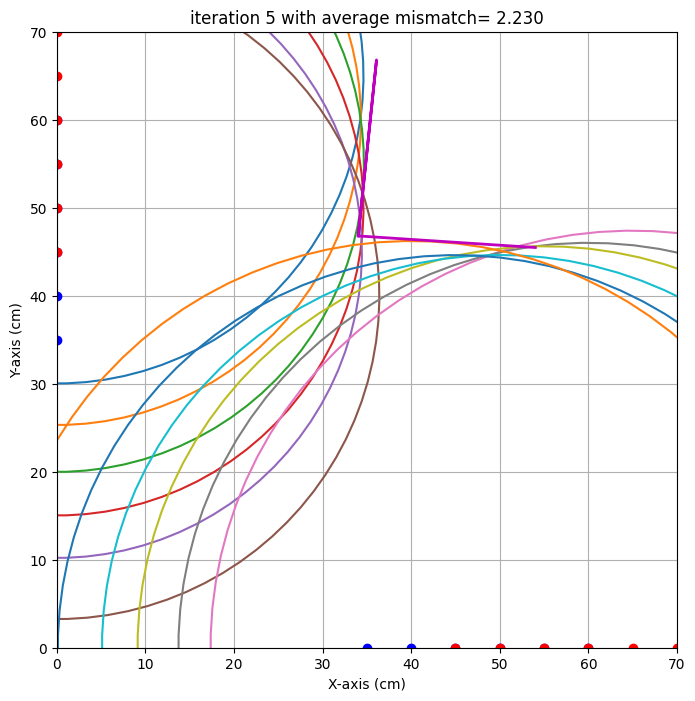

end iteration 5 with average mismatch= 2.230


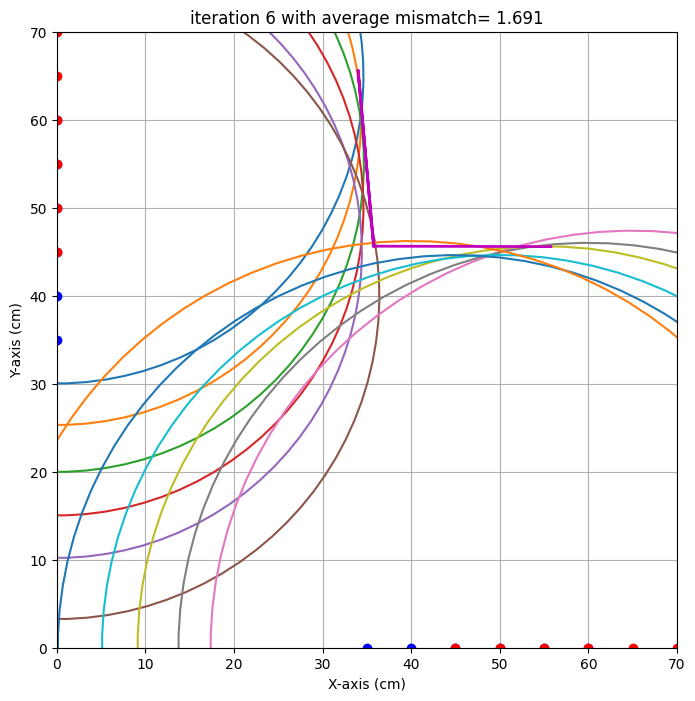

end iteration 6 with average mismatch= 1.691
end iteration 7 with average mismatch= 1.621
end iteration 8 with average mismatch= 1.495


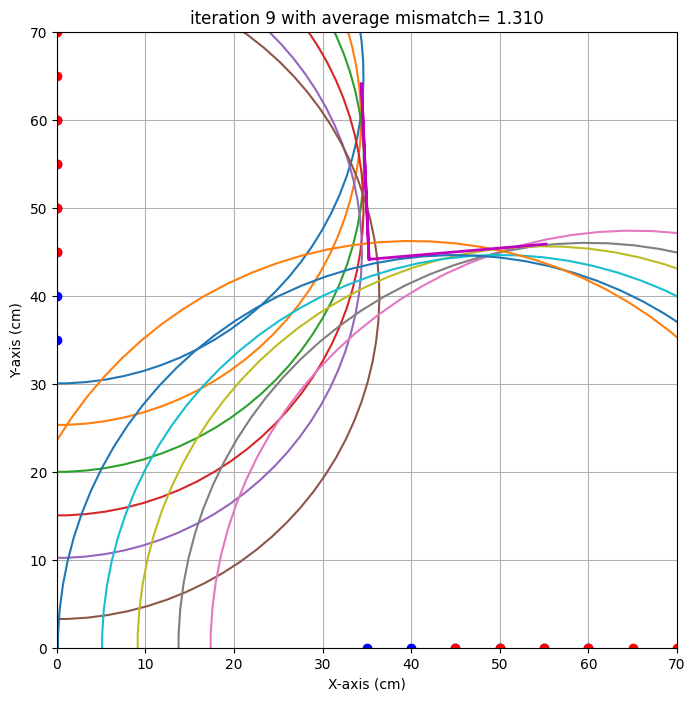

end iteration 9 with average mismatch= 1.310
end iteration 10 with average mismatch= 1.286
end iteration 11 with average mismatch= 1.252
end iteration 12 with average mismatch= 1.240
end iteration 13 with average mismatch= 1.237
end iteration 14 with average mismatch= 1.237
end iteration 15 with average mismatch= 1.237
end iteration 16 with average mismatch= 1.237
end iteration 17 with average mismatch= 1.237
end iteration 18 with average mismatch= 1.237
end iteration 19 with average mismatch= 1.237
end iteration 20 with average mismatch= 1.209
end iteration 21 with average mismatch= 1.209
end iteration 22 with average mismatch= 1.209
end iteration 23 with average mismatch= 1.209
end iteration 24 with average mismatch= 1.209
end iteration 25 with average mismatch= 1.209
end iteration 26 with average mismatch= 1.209
end iteration 27 with average mismatch= 1.209
end iteration 28 with average mismatch= 1.209
end iteration 29 with average mismatch= 1.209
Last iteration, also determine unce

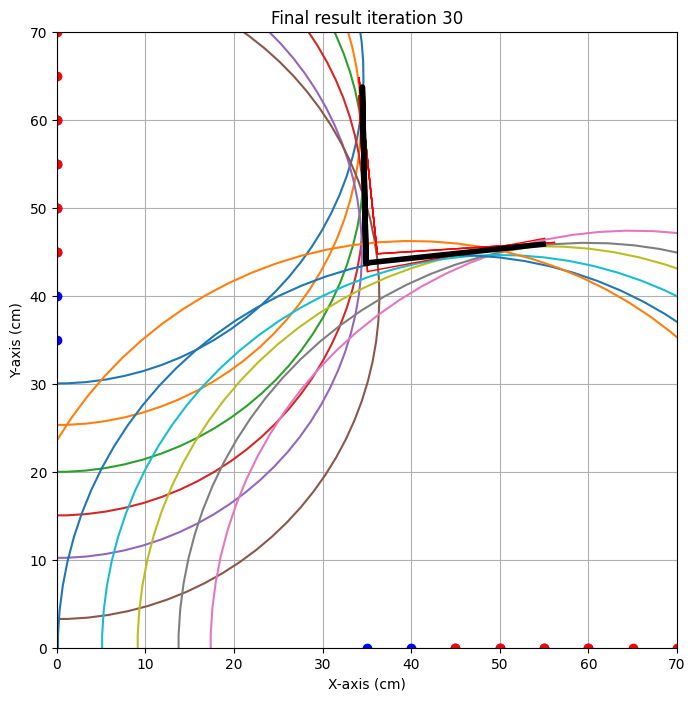

{'alpha': np.float64(6.102986214370231), 'alpha_eps': np.float64(4.5825469493686395), 'beta': np.float64(-1.206056439880536), 'beta_eps': np.float64(4.683974684444352), 'x0': np.float64(34.908625178995564), 'x0_eps': np.float64(1.2612171564104955), 'y0': np.float64(43.718152126660094), 'y0_eps': np.float64(1.0483545603342819)}
ShannonWerleman
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  70   0  60  70.23
1   0  50   0  60  69.05
2  40   0  50   0  86.70
3  45   0  55   0  88.31


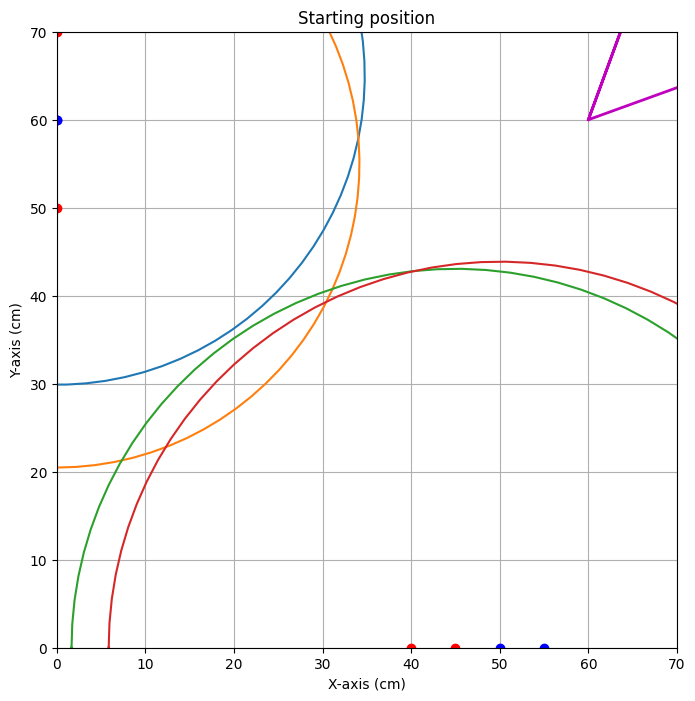


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=48.764


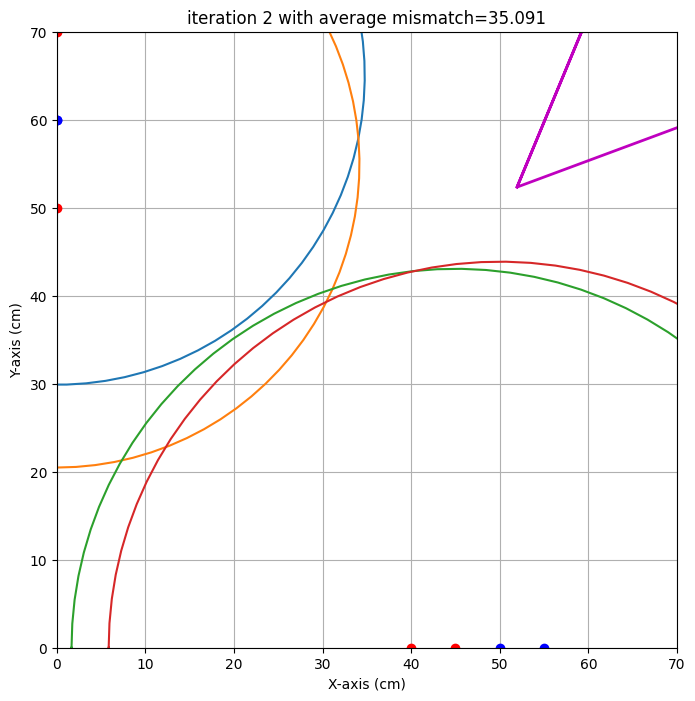

end iteration 2 with average mismatch=35.091


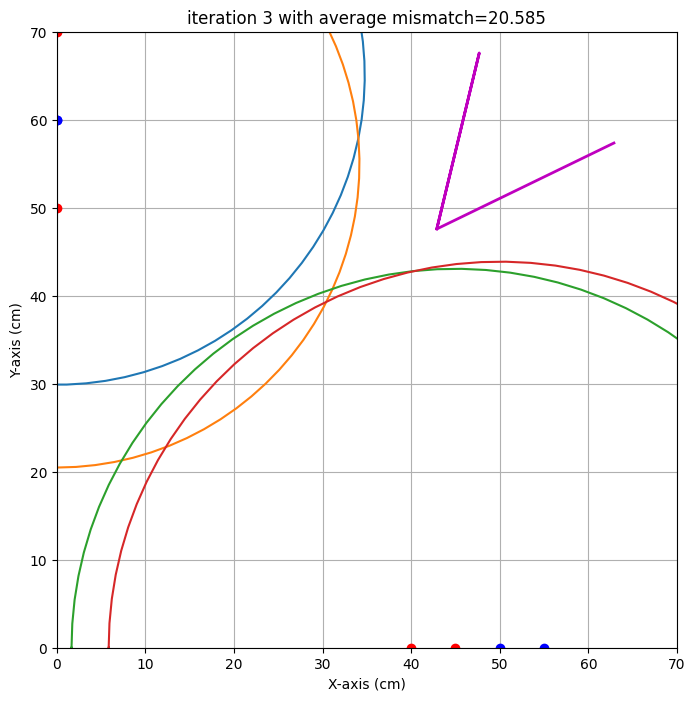

end iteration 3 with average mismatch=20.585


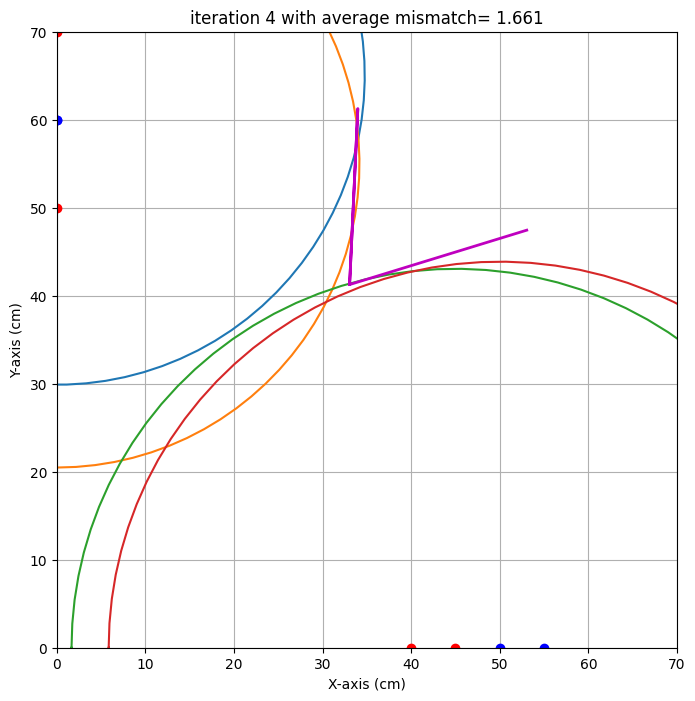

end iteration 4 with average mismatch= 1.661


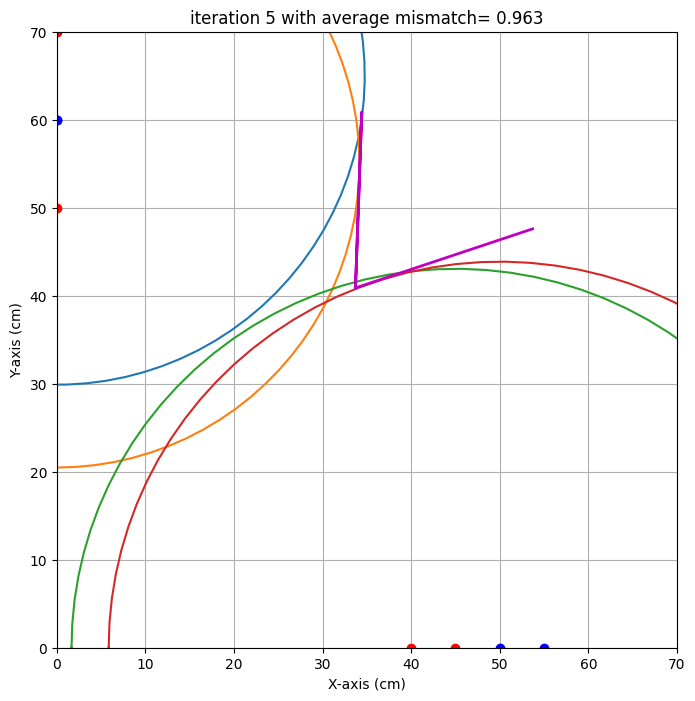

end iteration 5 with average mismatch= 0.963
end iteration 6 with average mismatch= 0.963
end iteration 7 with average mismatch= 0.963
end iteration 8 with average mismatch= 0.963
end iteration 9 with average mismatch= 0.963
end iteration 10 with average mismatch= 0.963


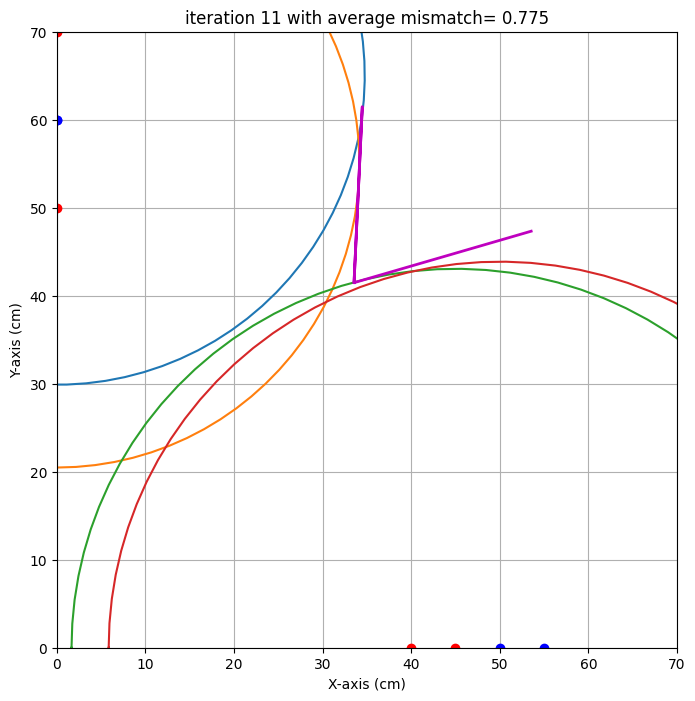

end iteration 11 with average mismatch= 0.775
end iteration 12 with average mismatch= 0.775
end iteration 13 with average mismatch= 0.775
end iteration 14 with average mismatch= 0.775
end iteration 15 with average mismatch= 0.775
end iteration 16 with average mismatch= 0.775
end iteration 17 with average mismatch= 0.775


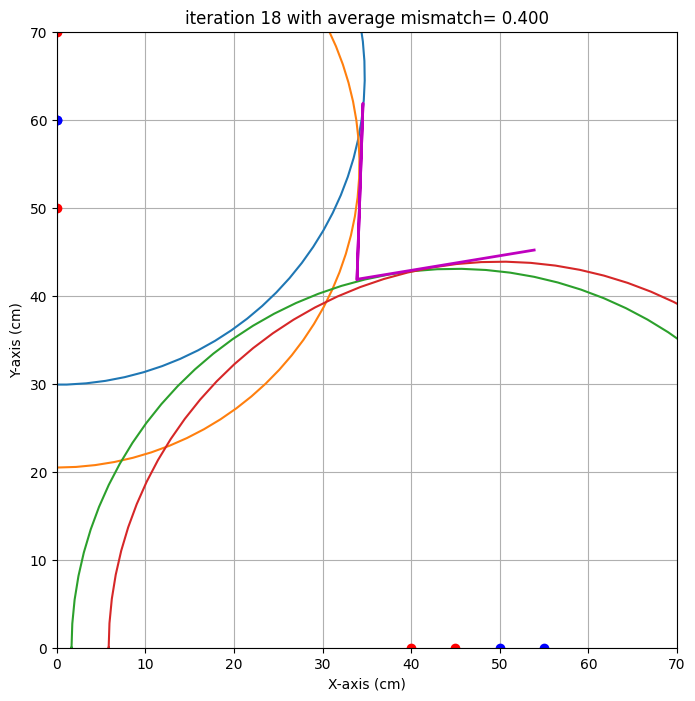

end iteration 18 with average mismatch= 0.400
end iteration 19 with average mismatch= 0.390
end iteration 20 with average mismatch= 0.389
end iteration 21 with average mismatch= 0.389
end iteration 22 with average mismatch= 0.389
end iteration 23 with average mismatch= 0.389
end iteration 24 with average mismatch= 0.389


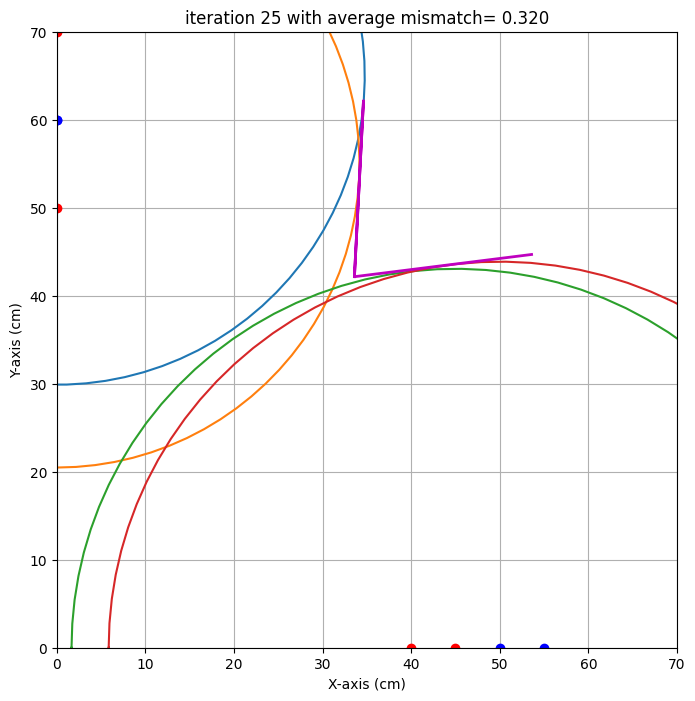

end iteration 25 with average mismatch= 0.320
end iteration 26 with average mismatch= 0.307
end iteration 27 with average mismatch= 0.307
end iteration 28 with average mismatch= 0.307
end iteration 29 with average mismatch= 0.307
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.307
###############################################################################
end of iteration  30
Best alpha=   7.19 with uncertainty=   3.80
Best beta =   2.90 with uncertainty=   3.57
Best x0   =  33.56 with uncertainty=   0.45
Best y0   =  42.16 with uncertainty=   0.46
###############################################################################


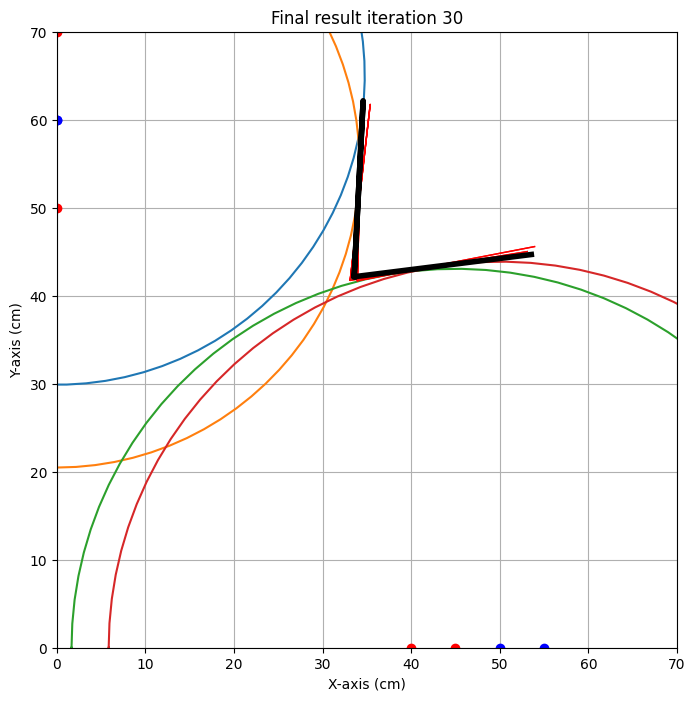

{'alpha': np.float64(7.193376779946686), 'alpha_eps': np.float64(3.801458630302239), 'beta': np.float64(2.901391166214789), 'beta_eps': np.float64(3.565796961432178), 'x0': np.float64(33.562225997798436), 'x0_eps': np.float64(0.45393360127817317), 'y0': np.float64(42.15908764720942), 'y0_eps': np.float64(0.46112092511222613)}
CasperJansen
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0  70   0  60   0  97.50
1   0  49   0  59  70.30
2   0  59   0  69  69.50
3   0  39   0  49  69.85
4  60   0  50   0  93.06


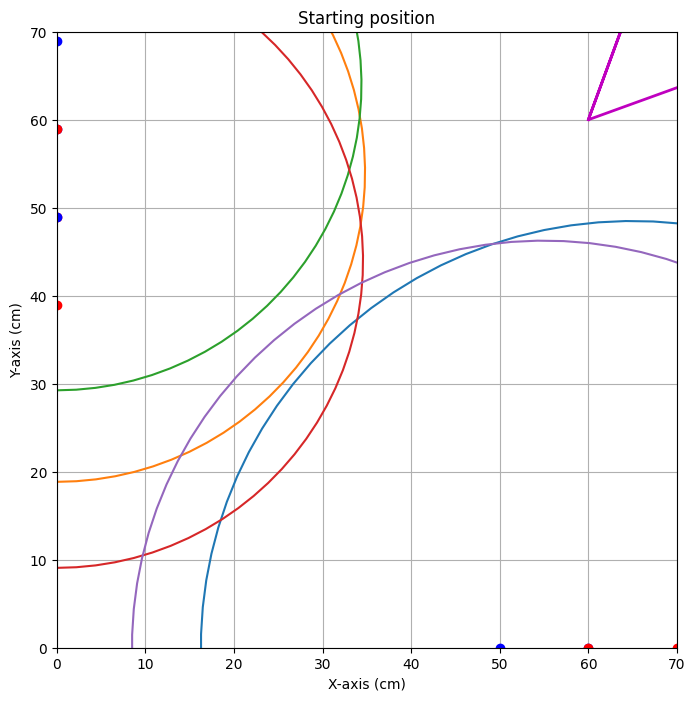


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=46.606


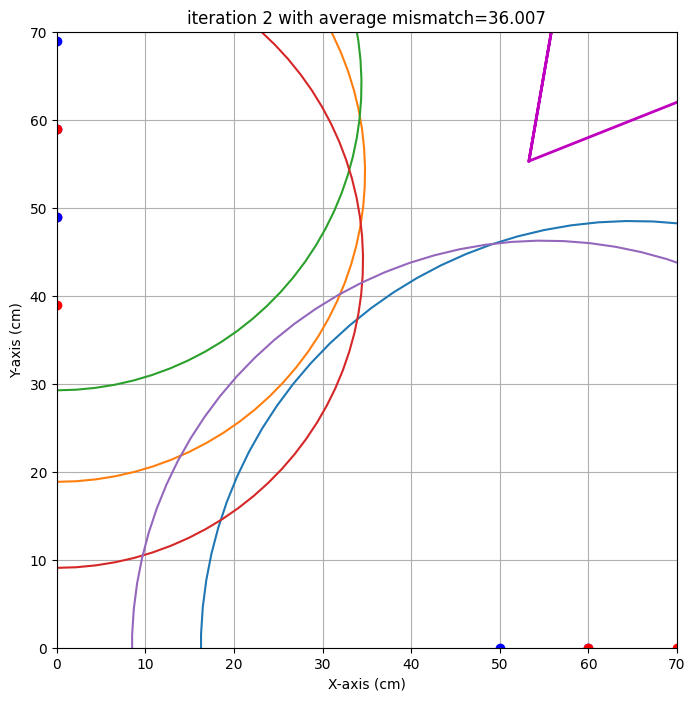

end iteration 2 with average mismatch=36.007


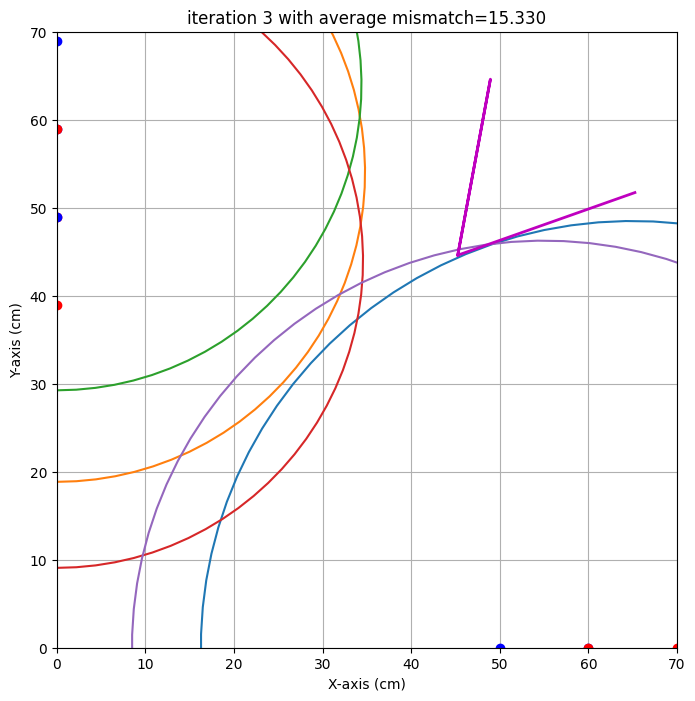

end iteration 3 with average mismatch=15.330


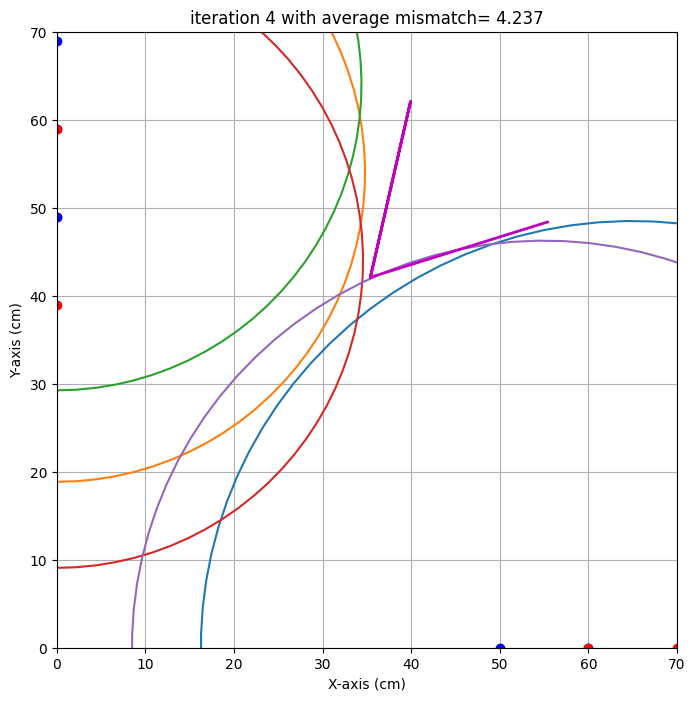

end iteration 4 with average mismatch= 4.237


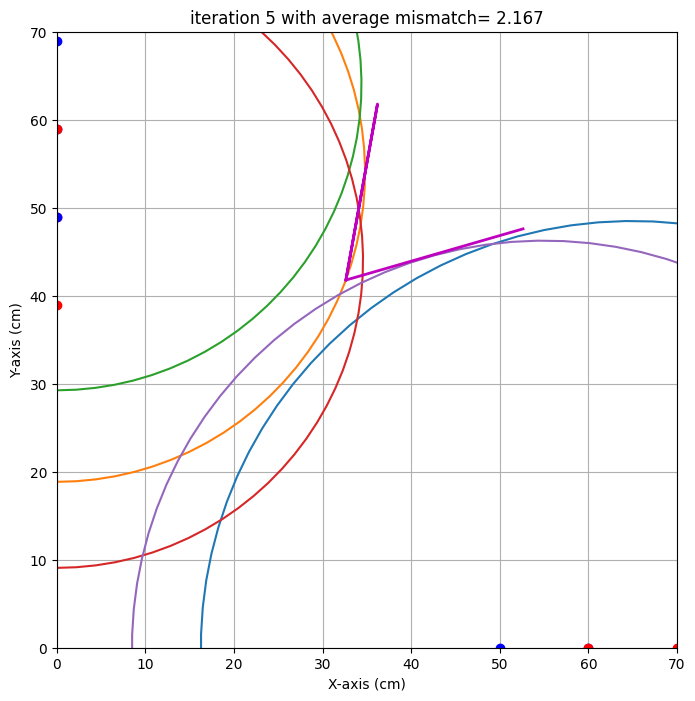

end iteration 5 with average mismatch= 2.167


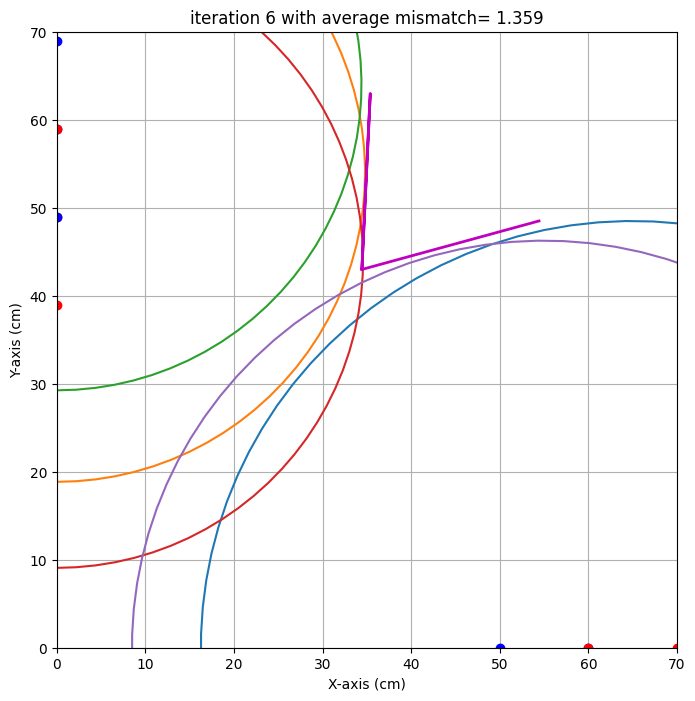

end iteration 6 with average mismatch= 1.359


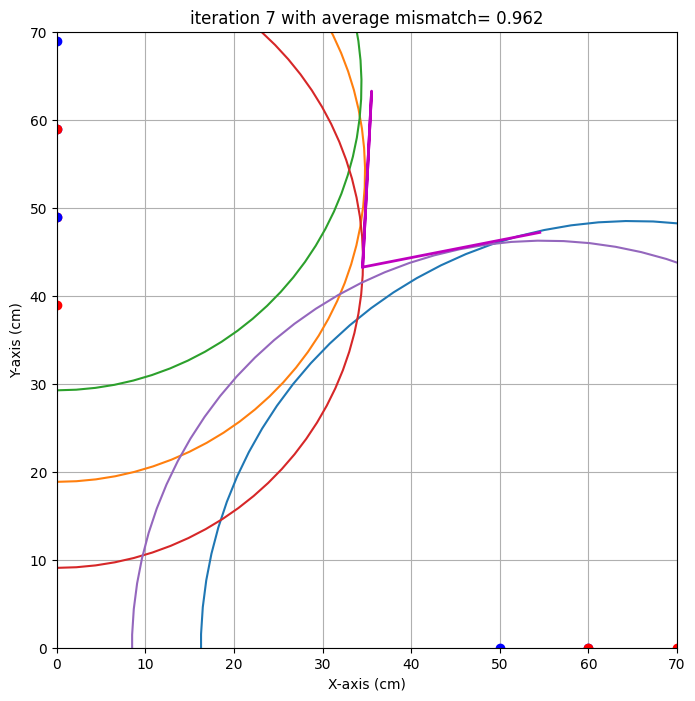

end iteration 7 with average mismatch= 0.962
end iteration 8 with average mismatch= 0.915
end iteration 9 with average mismatch= 0.889
end iteration 10 with average mismatch= 0.837
end iteration 11 with average mismatch= 0.837
end iteration 12 with average mismatch= 0.837
end iteration 13 with average mismatch= 0.837
end iteration 14 with average mismatch= 0.837
end iteration 15 with average mismatch= 0.837
end iteration 16 with average mismatch= 0.837


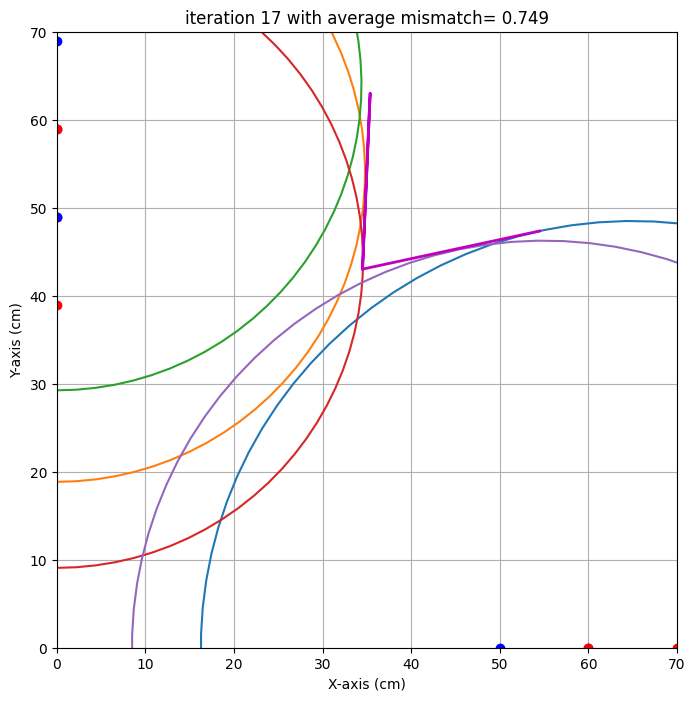

end iteration 17 with average mismatch= 0.749
end iteration 18 with average mismatch= 0.745
end iteration 19 with average mismatch= 0.744
end iteration 20 with average mismatch= 0.743
end iteration 21 with average mismatch= 0.743
end iteration 22 with average mismatch= 0.743
end iteration 23 with average mismatch= 0.743
end iteration 24 with average mismatch= 0.743
end iteration 25 with average mismatch= 0.743
end iteration 26 with average mismatch= 0.743
end iteration 27 with average mismatch= 0.743
end iteration 28 with average mismatch= 0.743
end iteration 29 with average mismatch= 0.743
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.743
###############################################################################
end of iteration  30
Best alpha=  12.22 with uncertainty=   3.93
Best beta =   2.46 with uncertainty=   4.91
Best x0   =  34.49 with uncertainty=   0.57
Best y0   =  4

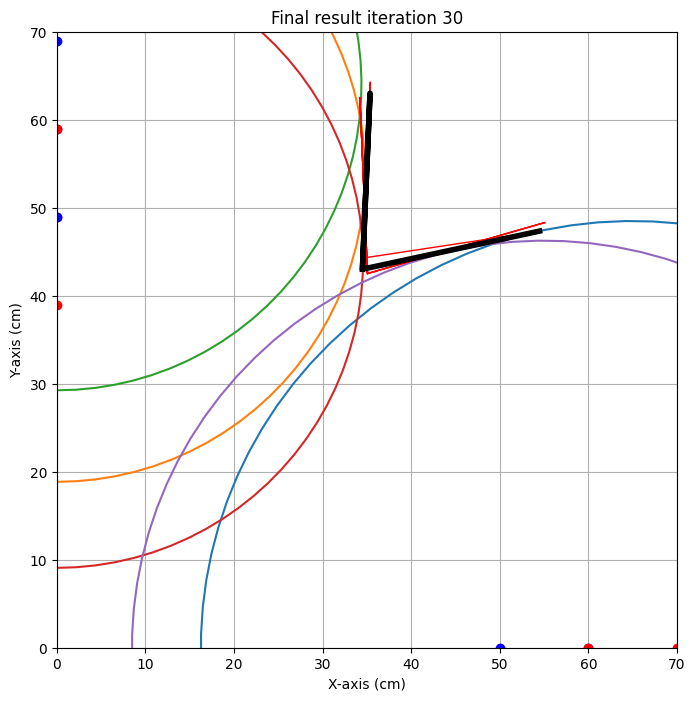

{'alpha': np.float64(12.216799795231639), 'alpha_eps': np.float64(3.927368614776322), 'beta': np.float64(2.462242397832803), 'beta_eps': np.float64(4.913436407931961), 'x0': np.float64(34.49345382033734), 'x0_eps': np.float64(0.5728875990806728), 'y0': np.float64(43.01405358857833), 'y0_eps': np.float64(1.2726230378622745)}


In [7]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [8]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

ChristophSmit 
x0 target is : 35.5. Gevonden waarde: 34.9 cm met een standaardafwijking van 1.3 cm 
y0 target is : 41.9. Gevonden waarde: 43.7 cm met een standaardafwijking van 1.0 cm 
alpha target is : 7.0. Gevonden waarde: 6.1 graden met een standaardafwijking van 4.6 graad 
beta target is : 0.0. Gevonden waarde: -1.2 graden met een standaardafwijking van 4.7 graad 

ShannonWerleman 
x0 target is : 35.5. Gevonden waarde: 33.6 cm met een standaardafwijking van 0.5 cm 
y0 target is : 41.9. Gevonden waarde: 42.2 cm met een standaardafwijking van 0.5 cm 
alpha target is : 7.0. Gevonden waarde: 7.2 graden met een standaardafwijking van 3.8 graad 
beta target is : 0.0. Gevonden waarde: 2.9 graden met een standaardafwijking van 3.6 graad 

CasperJansen 
x0 target is : 35.5. Gevonden waarde: 34.5 cm met een standaardafwijking van 0.6 cm 
y0 target is : 41.9. Gevonden waarde: 43.0 cm met een standaardafwijking van 1.3 cm 
alpha target is : 7.0. Gevonden waarde: 12.2 graden met een standaardaf

## Opdracht 8: Iteratie1+ 14:51.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur:
<img src="iteratie1.jpeg" width="400">
<img src="iteratiefinal.jpeg" width="400">



## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs  ys  xr  yr       R
0   0  70   0  60   55.41
1  28   0  38   0   97.43
2  18   0  28   0  102.36


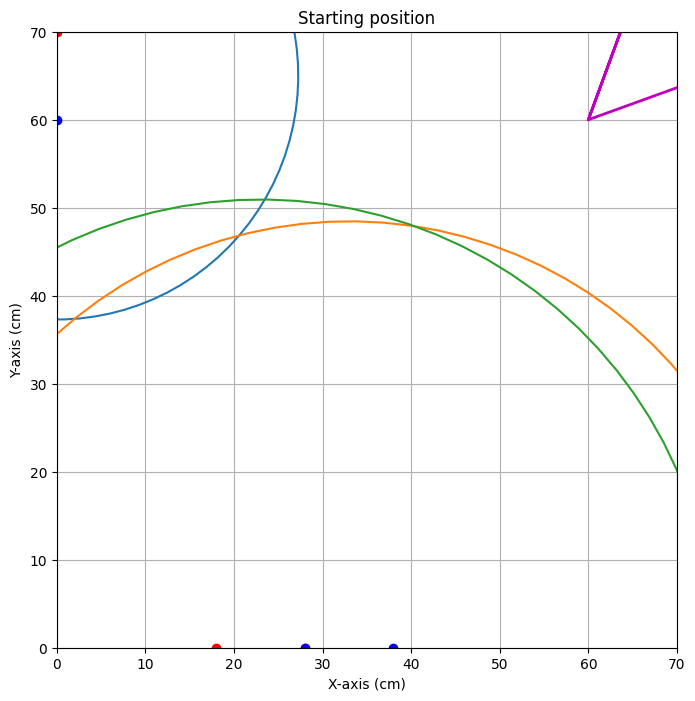


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=52.406


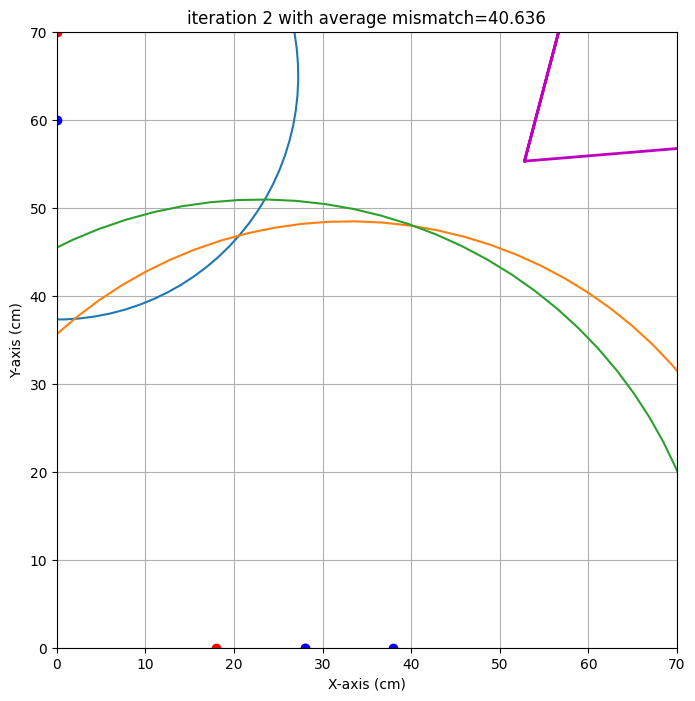

end iteration 2 with average mismatch=40.636


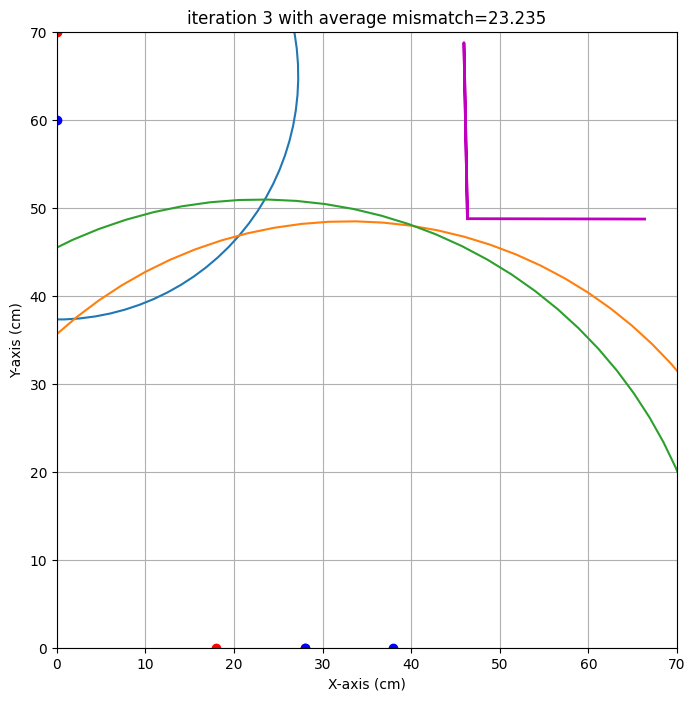

end iteration 3 with average mismatch=23.235


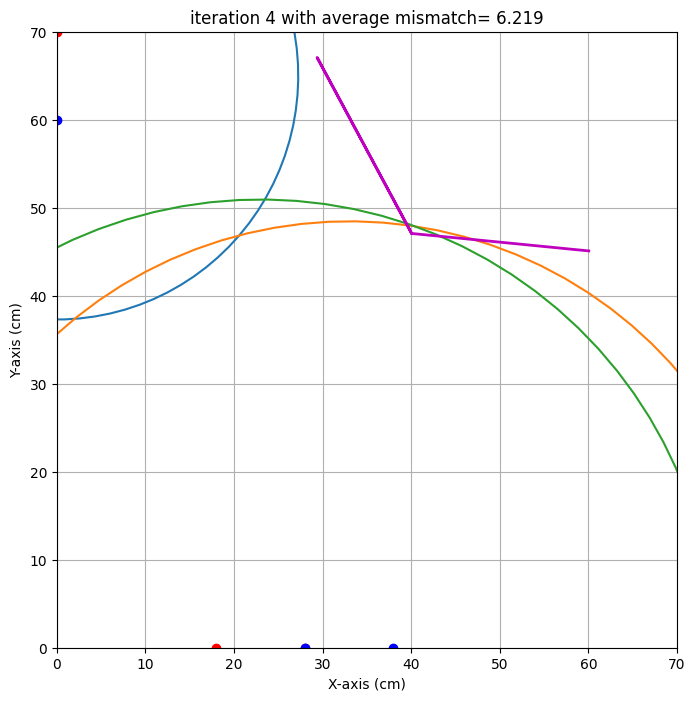

end iteration 4 with average mismatch= 6.219


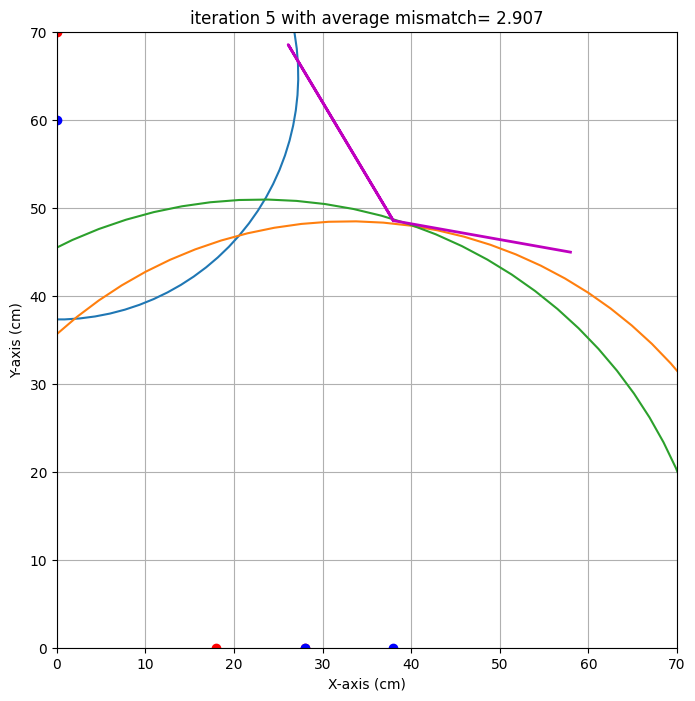

end iteration 5 with average mismatch= 2.907


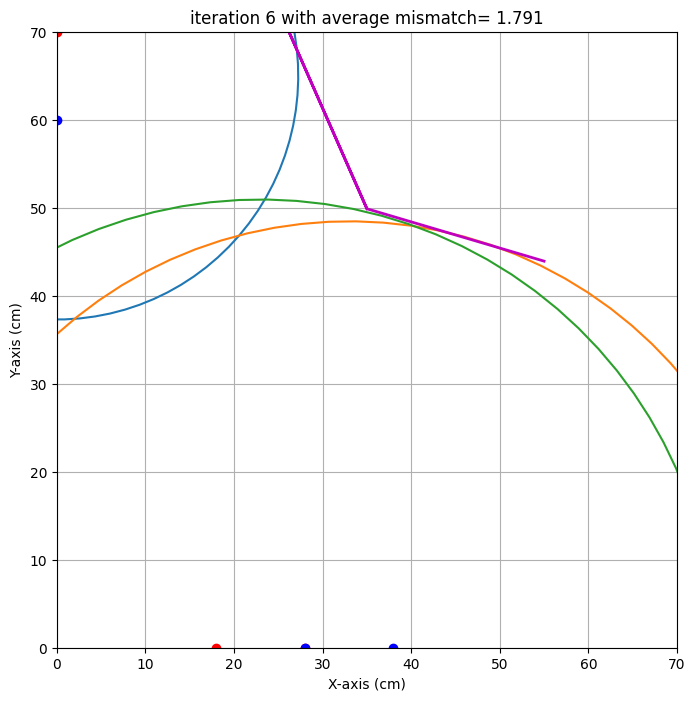

end iteration 6 with average mismatch= 1.791


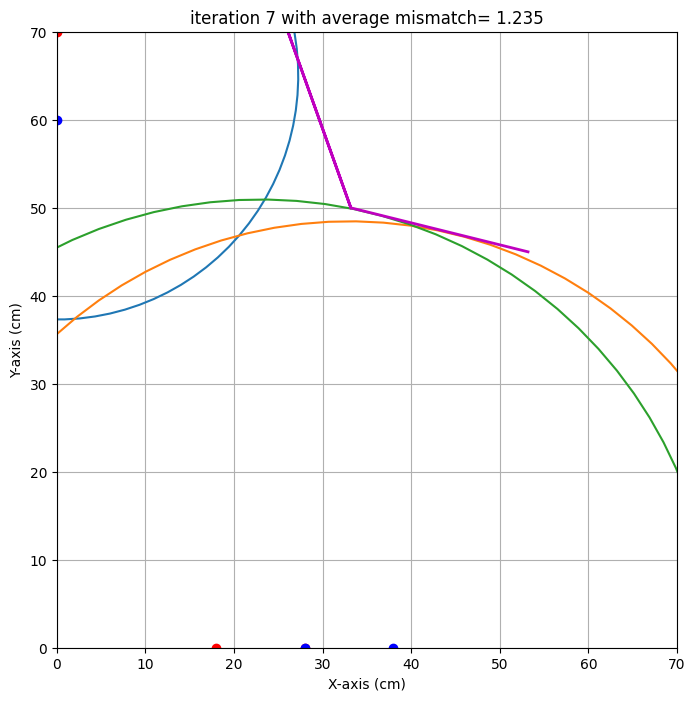

end iteration 7 with average mismatch= 1.235
end iteration 8 with average mismatch= 1.209


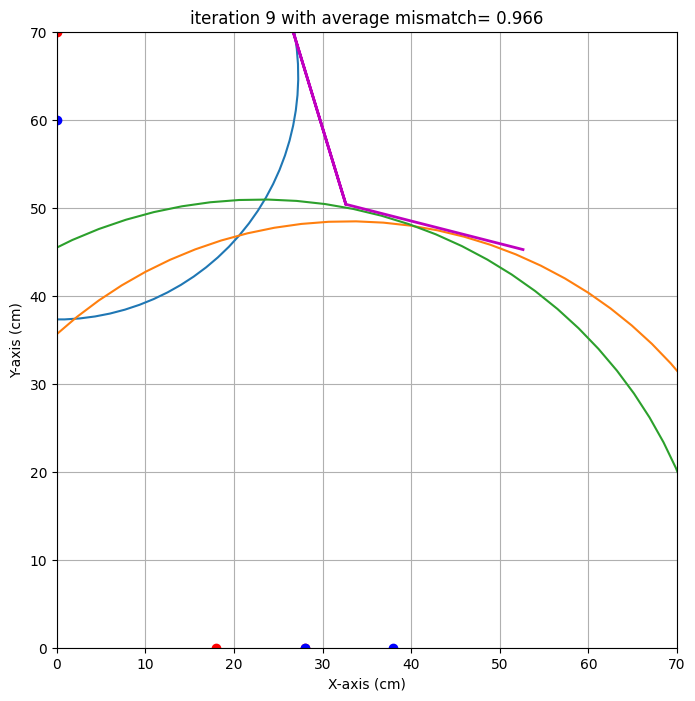

end iteration 9 with average mismatch= 0.966


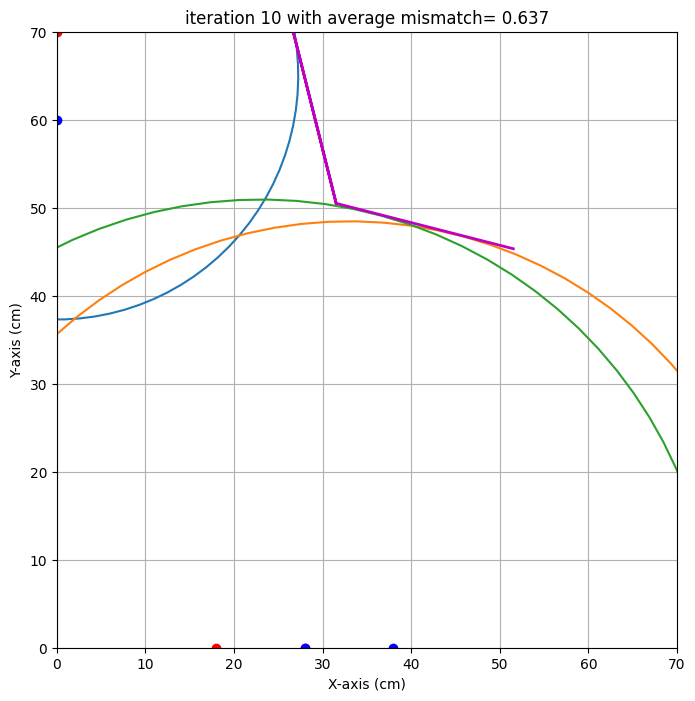

end iteration 10 with average mismatch= 0.637


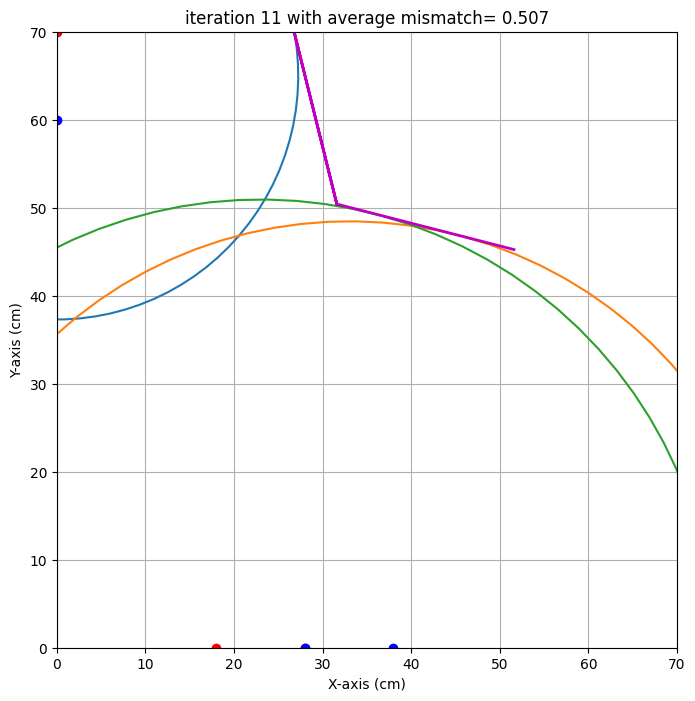

end iteration 11 with average mismatch= 0.507
end iteration 12 with average mismatch= 0.491
end iteration 13 with average mismatch= 0.490
end iteration 14 with average mismatch= 0.444
end iteration 15 with average mismatch= 0.444


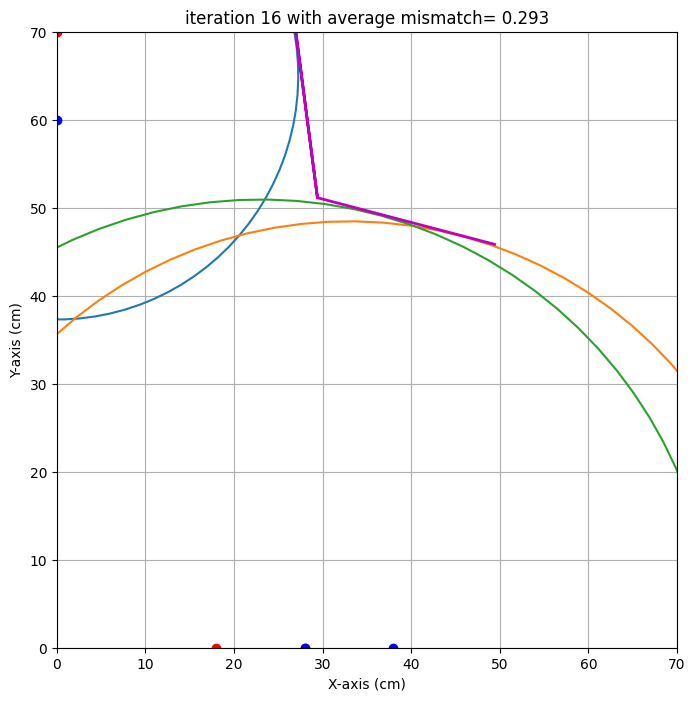

end iteration 16 with average mismatch= 0.293


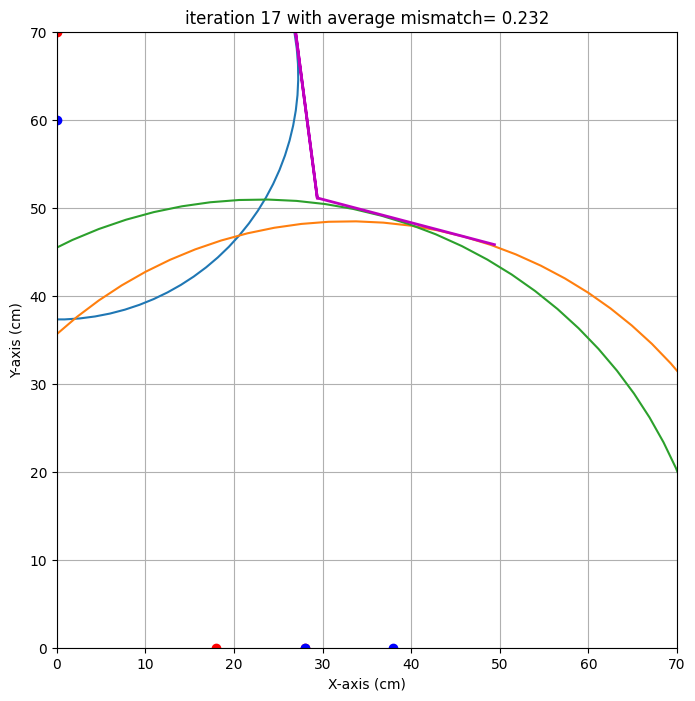

end iteration 17 with average mismatch= 0.232


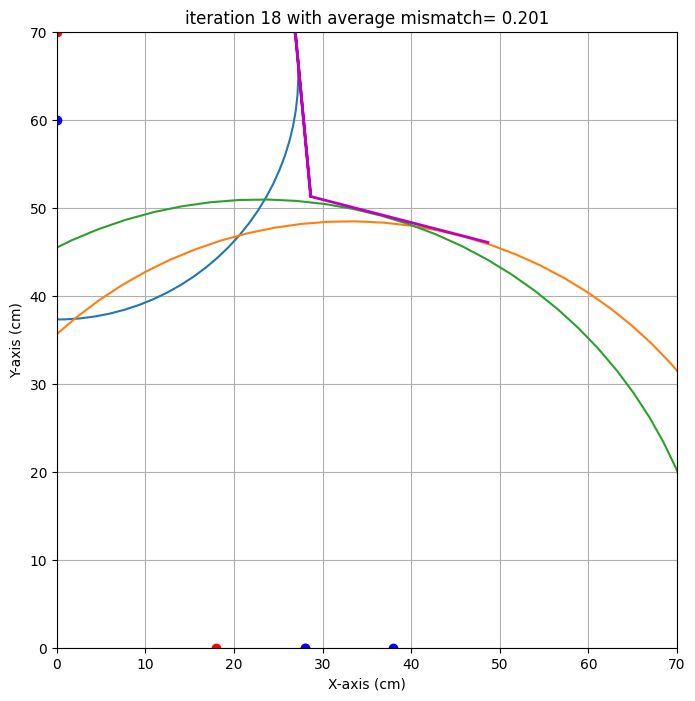

end iteration 18 with average mismatch= 0.201
end iteration 19 with average mismatch= 0.182


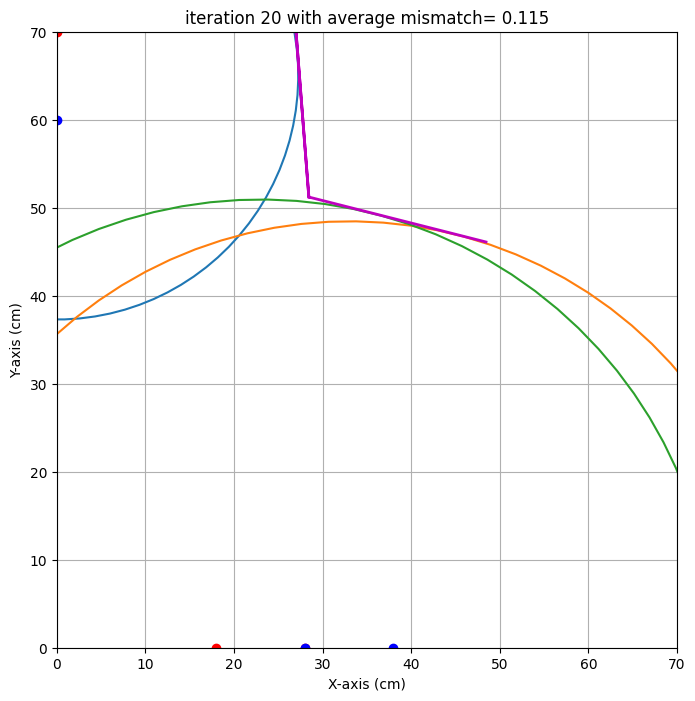

end iteration 20 with average mismatch= 0.115


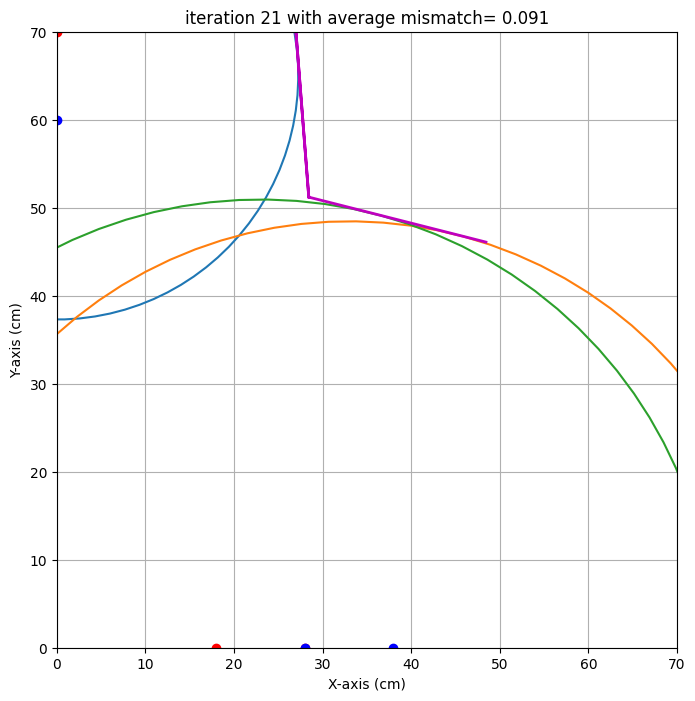

end iteration 21 with average mismatch= 0.091


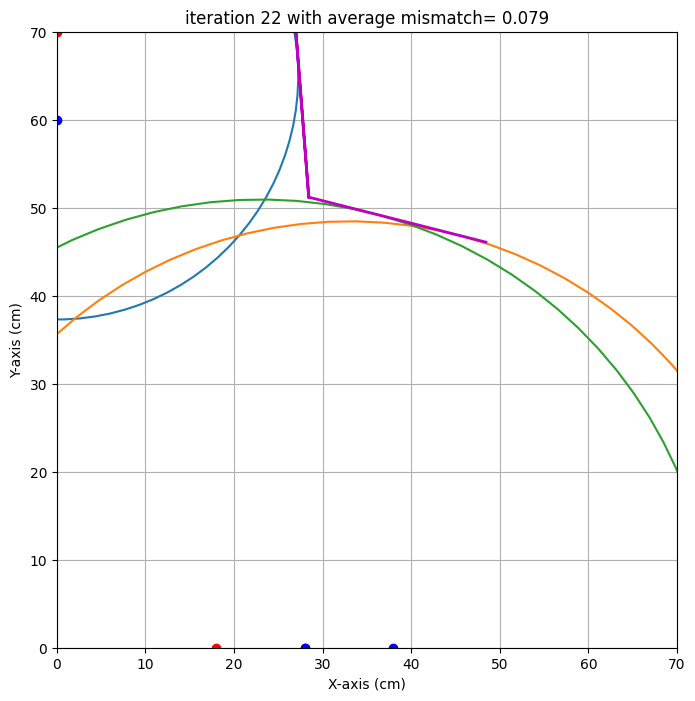

end iteration 22 with average mismatch= 0.079
end iteration 23 with average mismatch= 0.078
end iteration 24 with average mismatch= 0.078
end iteration 25 with average mismatch= 0.078
end iteration 26 with average mismatch= 0.078
end iteration 27 with average mismatch= 0.078
end iteration 28 with average mismatch= 0.078
end iteration 29 with average mismatch= 0.078
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.078
###############################################################################
end of iteration  30
Best alpha= -14.33 with uncertainty=   0.90
Best beta =  -4.42 with uncertainty=  12.13
Best x0   =  28.43 with uncertainty=   4.68
Best y0   =  51.20 with uncertainty=   1.42
###############################################################################


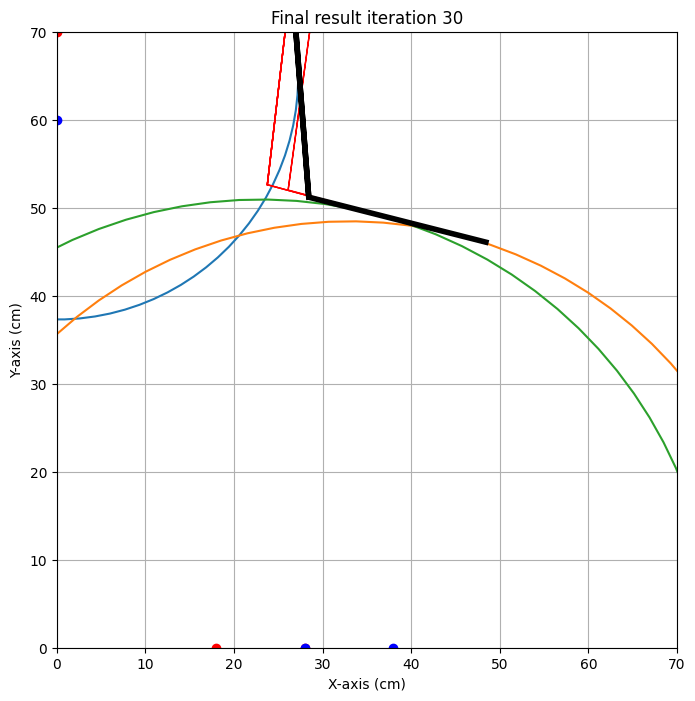

{'alpha': np.float64(-14.334305882284491), 'alpha_eps': np.float64(0.9030045122244346), 'beta': np.float64(-4.419321004734295), 'beta_eps': np.float64(12.126326779127057), 'x0': np.float64(28.434788321978807), 'x0_eps': np.float64(4.6800579932264625), 'y0': np.float64(51.195965487871874), 'y0_eps': np.float64(1.4176144829053712)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  60   0  50  67.53
1   0  55   0  45  66.31
2   0  50   0  40  70.03
3   0  45   0  35  71.13
4   0  40   0  30  71.40
5  40   0  50   0  74.20
6  45   0  55   0  75.02
7  50   0  60   0  76.02
8  55   0  65   0  78.42


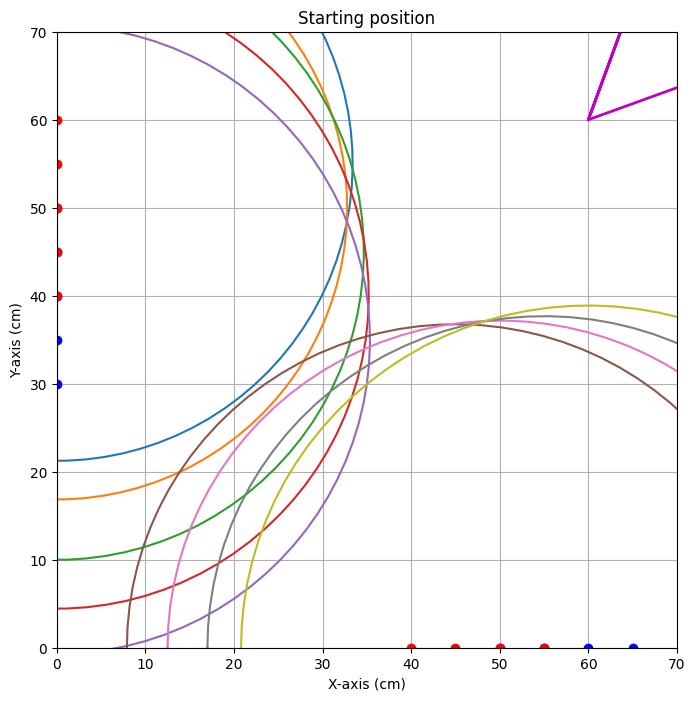


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=57.410


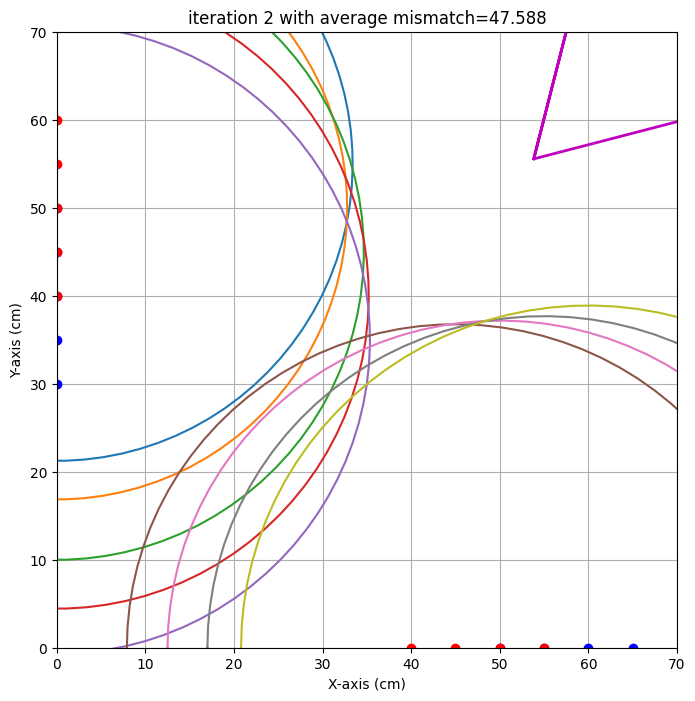

end iteration 2 with average mismatch=47.588


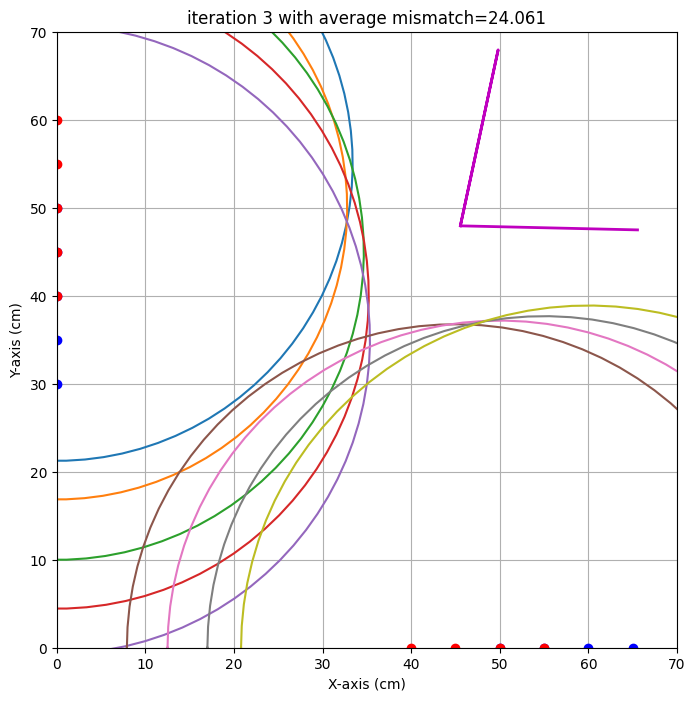

end iteration 3 with average mismatch=24.061


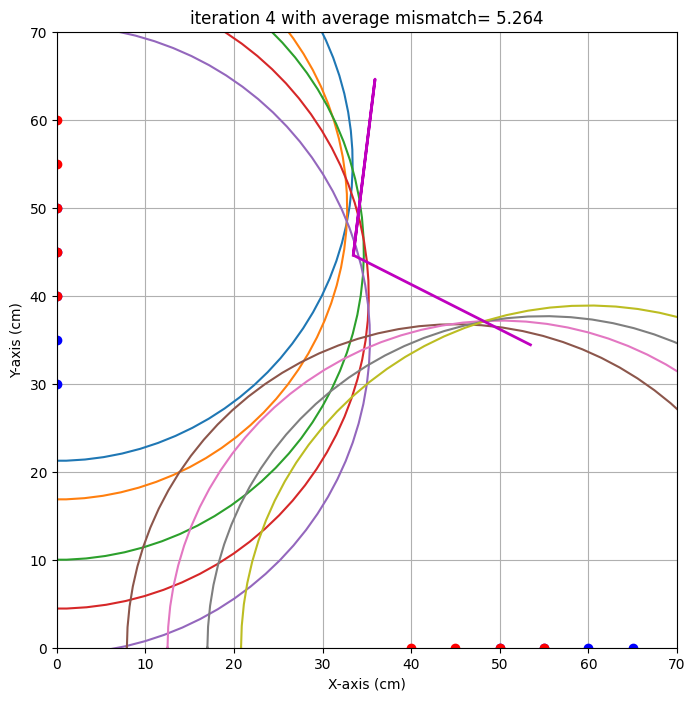

end iteration 4 with average mismatch= 5.264


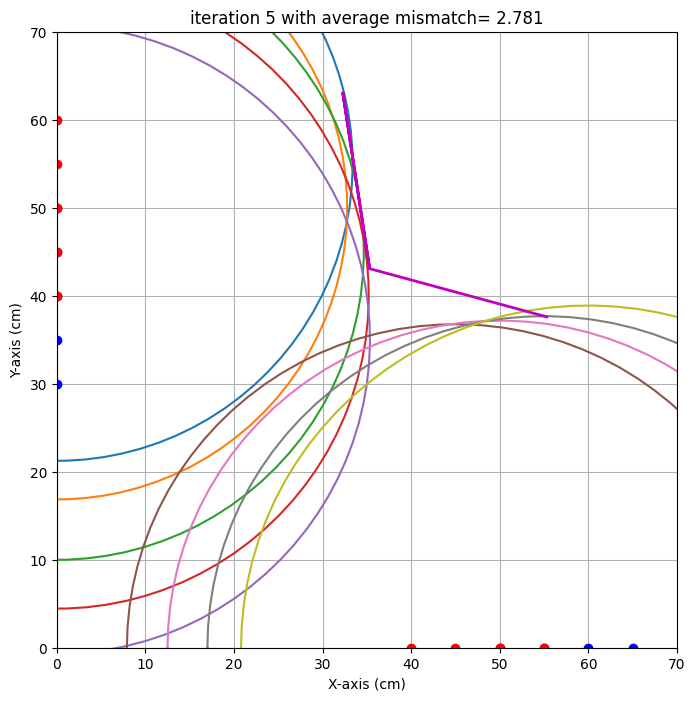

end iteration 5 with average mismatch= 2.781


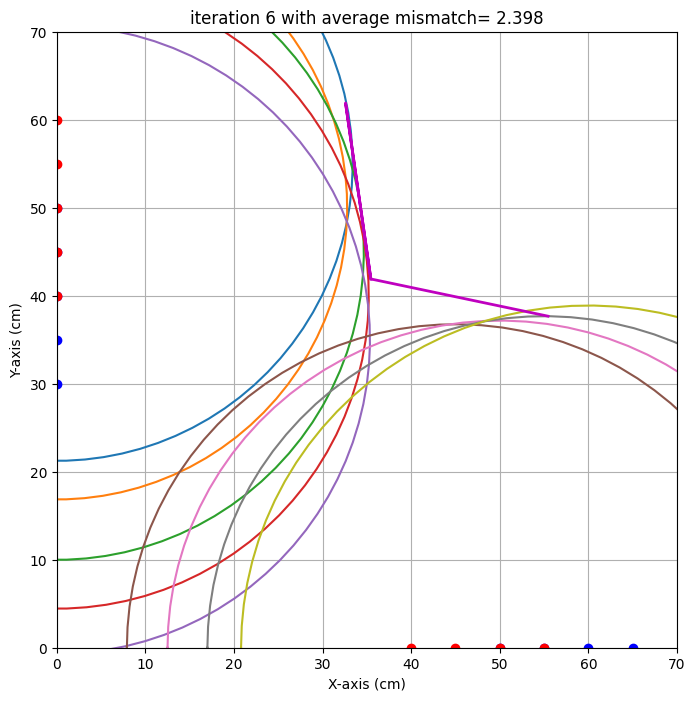

end iteration 6 with average mismatch= 2.398


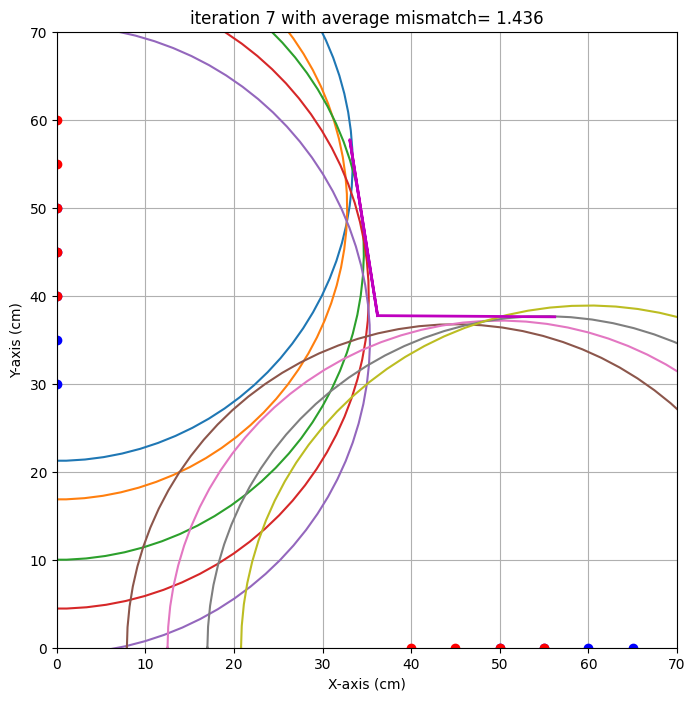

end iteration 7 with average mismatch= 1.436
end iteration 8 with average mismatch= 1.393
end iteration 9 with average mismatch= 1.391
end iteration 10 with average mismatch= 1.326


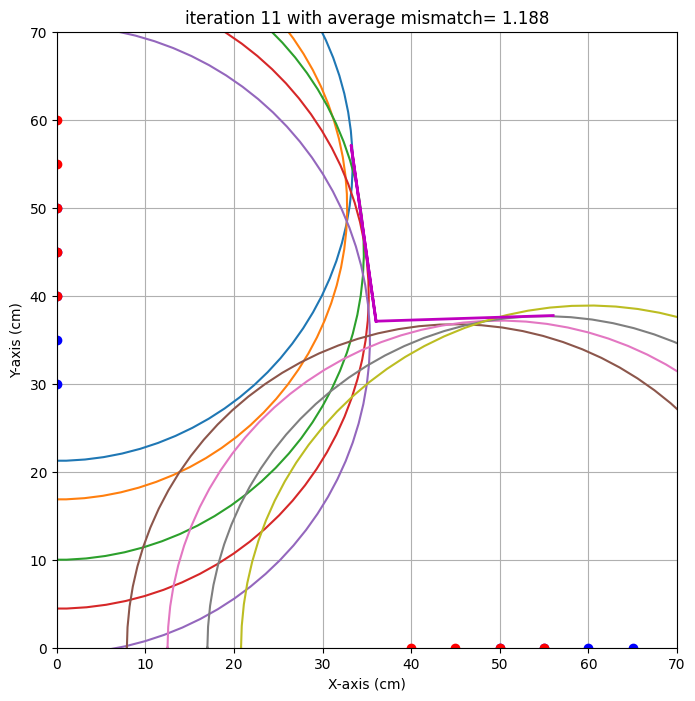

end iteration 11 with average mismatch= 1.188
end iteration 12 with average mismatch= 1.187
end iteration 13 with average mismatch= 1.186
end iteration 14 with average mismatch= 1.186
end iteration 15 with average mismatch= 1.185
end iteration 16 with average mismatch= 1.158
end iteration 17 with average mismatch= 1.081
end iteration 18 with average mismatch= 1.068
end iteration 19 with average mismatch= 1.064
end iteration 20 with average mismatch= 1.063
end iteration 21 with average mismatch= 1.057
end iteration 22 with average mismatch= 1.048
end iteration 23 with average mismatch= 1.043
end iteration 24 with average mismatch= 0.969
end iteration 25 with average mismatch= 0.962
end iteration 26 with average mismatch= 0.962
end iteration 27 with average mismatch= 0.962
end iteration 28 with average mismatch= 0.962
end iteration 29 with average mismatch= 0.962
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 

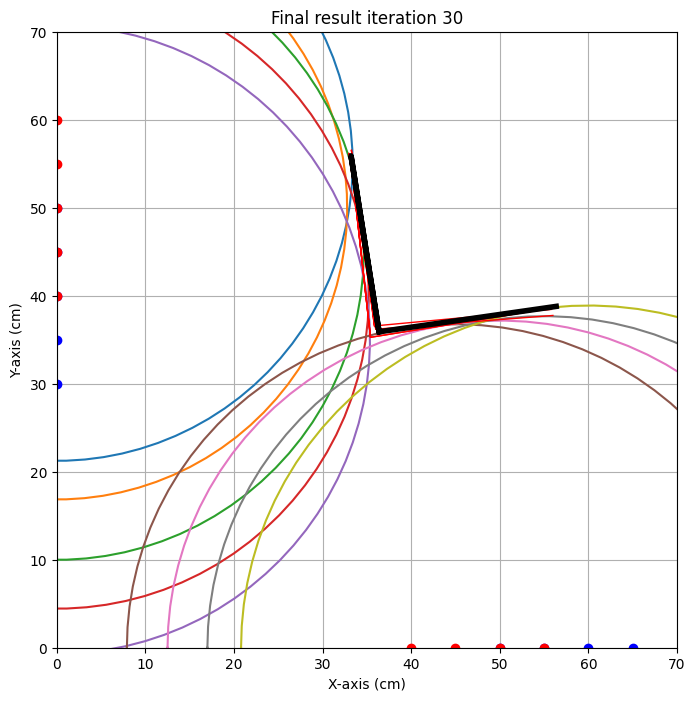

{'alpha': np.float64(8.215160017432265), 'alpha_eps': np.float64(3.7495567631119133), 'beta': np.float64(-8.990641220455288), 'beta_eps': np.float64(2.7012456969125997), 'x0': np.float64(36.37157459804322), 'x0_eps': np.float64(0.9651227626928573), 'y0': np.float64(35.899865755057455), 'y0_eps': np.float64(0.6654083842939258)}
locatie 1 
x0 target is : 25.7. Gevonden waarde: 28.4 cm met een standaardafwijking van 4.7 cm 
y0 target is : 52.8. Gevonden waarde: 51.2 cm met een standaardafwijking van 1.4 cm 
alpha target is : -15.0. Gevonden waarde: -14.3 graden met een standaardafwijking van 0.9 graad 
beta target is : 14.0. Gevonden waarde: -4.4 graden met een standaardafwijking van 12.1 graad 

locatie 2 
x0 target is : 36.7. Gevonden waarde: 36.4 cm met een standaardafwijking van 1.0 cm 
y0 target is : 36.0. Gevonden waarde: 35.9 cm met een standaardafwijking van 0.7 cm 
alpha target is : 7.0. Gevonden waarde: 8.2 graden met een standaardafwijking van 3.7 graad 
beta target is : -6.0. 

In [9]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0':25.7,
                    'y0':52.8,
                    'alpha' : -15,
                    'beta' : 14},
           'locatie 2':{'x0':36.7,
                    'y0':36,
                    'alpha' :7,
                    'beta' : -6}
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,70,0,60,55.41],
    #[0,60,0,50,ongeldig]
    [28,0,38,0,97.43],
    #[38,0,48,0,ongeldig]
    [18,0,28,0,102.36]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,70,0,60,ongeldig],
    [0,60,0,50,67.53],
    [0,55,0,45,66.31],
    [0,50,0,40,70.03],
    [0,45,0,35,71.13],
    [0,40,0,30,71.40],
    #[0,35,0,25,79.30],
    #[35,0,45,0,77.5],
    [40,0,50,0,74.2],
    [45,0,55,0,75.02],
    [50,0,60,0,76.02],
    [55,0,65,0,78.42],
    #[60,0,70,0,82.0]

    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  70   0  60  47.15
1   0  65   0  55  46.84
2   0  60   0  50  46.66
3   0  55   0  45  45.60
4   0  50   0  40  45.25
5  25   0  35   0  82.44
6  30   0  40   0  83.52
7  35   0  45   0  85.16
8  40   0  50   0  86.36
9  45   0  55   0  88.90


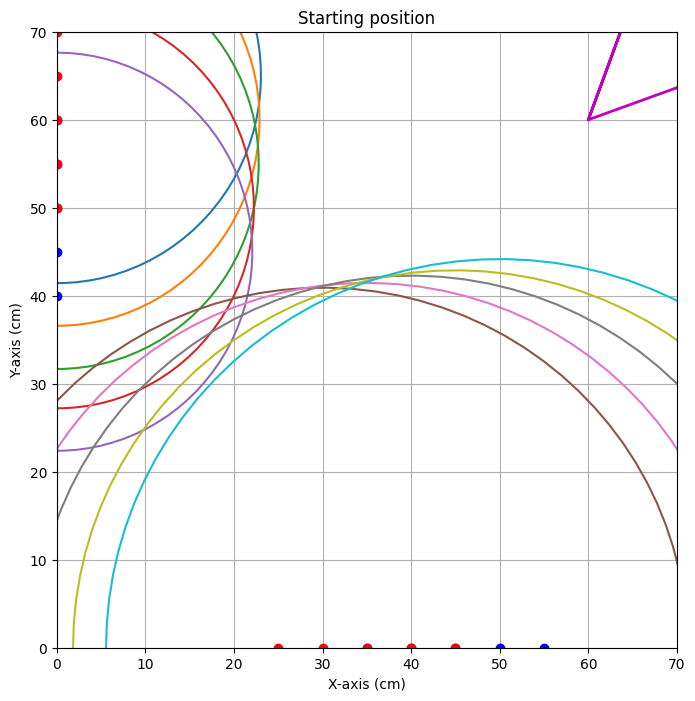


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=64.509


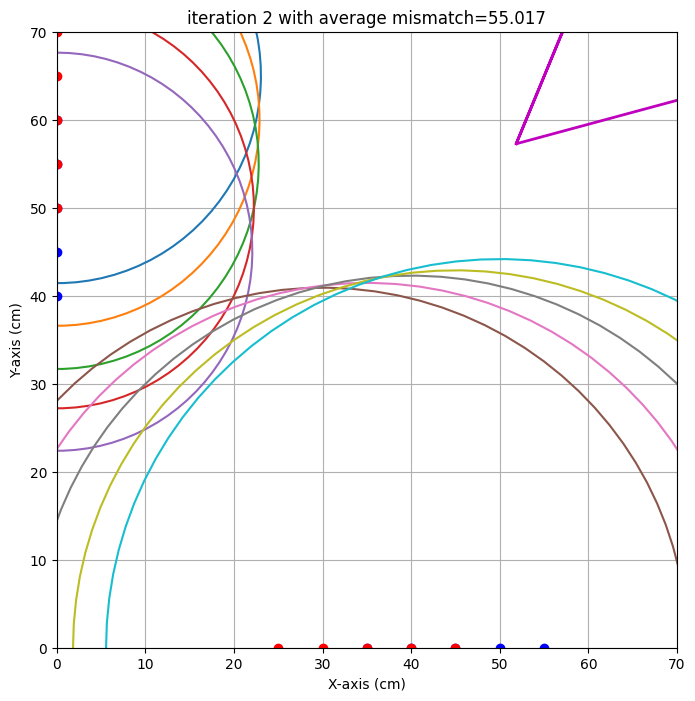

end iteration 2 with average mismatch=55.017


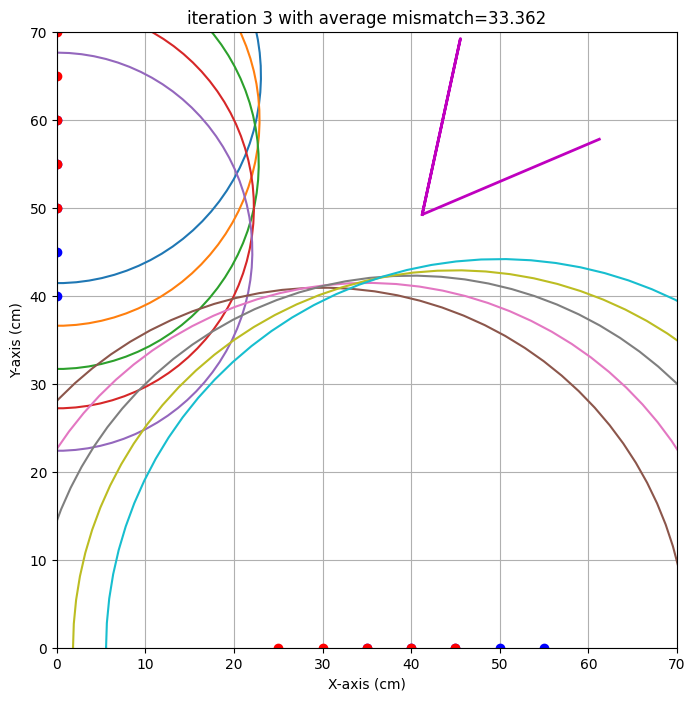

end iteration 3 with average mismatch=33.362


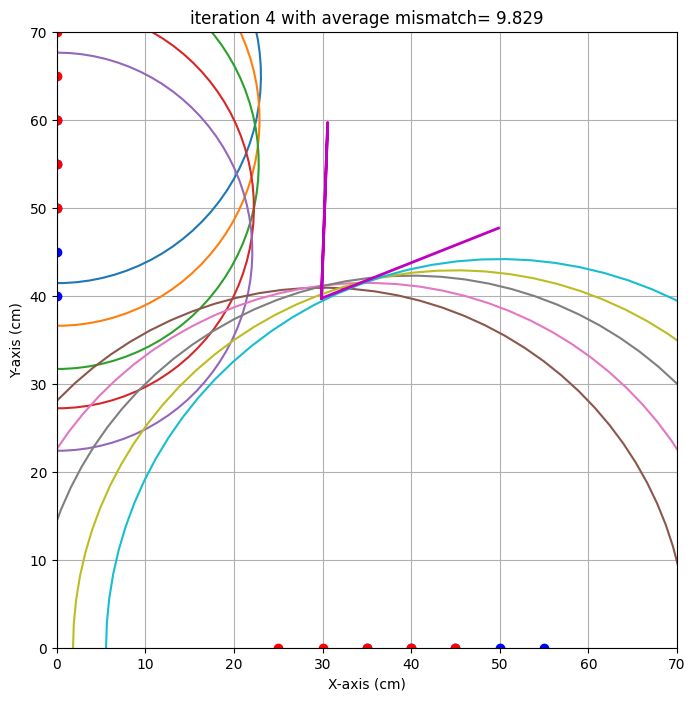

end iteration 4 with average mismatch= 9.829


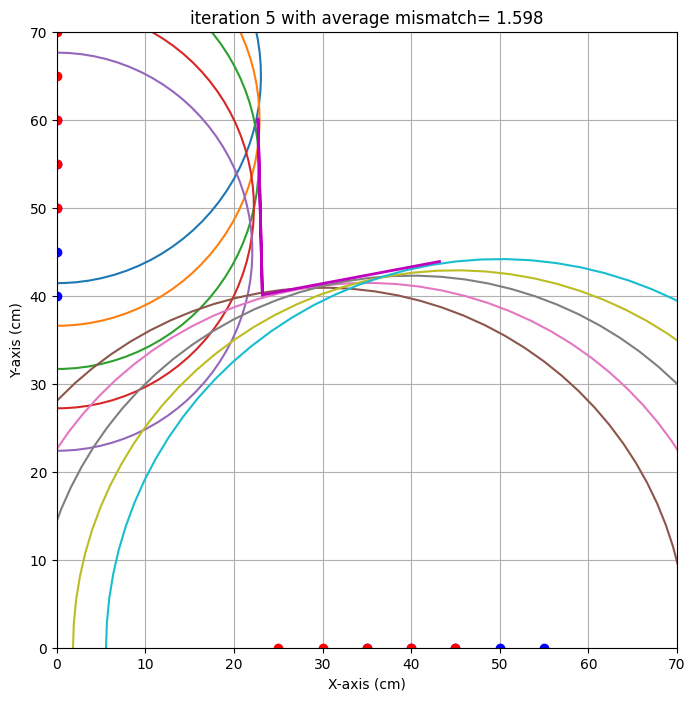

end iteration 5 with average mismatch= 1.598


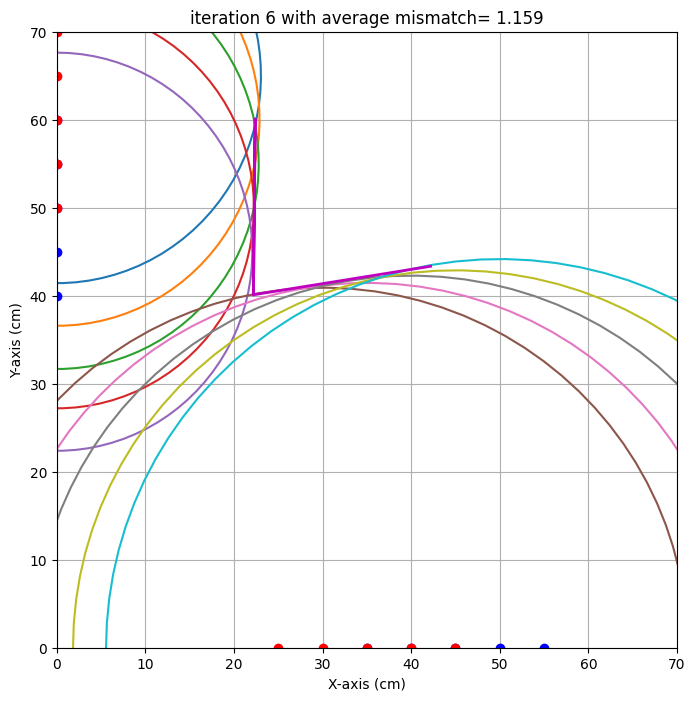

end iteration 6 with average mismatch= 1.159
end iteration 7 with average mismatch= 1.133
end iteration 8 with average mismatch= 1.133
end iteration 9 with average mismatch= 1.133
end iteration 10 with average mismatch= 1.133
end iteration 11 with average mismatch= 1.133
end iteration 12 with average mismatch= 1.133
end iteration 13 with average mismatch= 1.133
end iteration 14 with average mismatch= 1.133
end iteration 15 with average mismatch= 1.133
end iteration 16 with average mismatch= 1.133
end iteration 17 with average mismatch= 1.133
end iteration 18 with average mismatch= 1.133
end iteration 19 with average mismatch= 1.133
end iteration 20 with average mismatch= 1.120
end iteration 21 with average mismatch= 1.115
end iteration 22 with average mismatch= 1.115
end iteration 23 with average mismatch= 1.114
end iteration 24 with average mismatch= 1.114
end iteration 25 with average mismatch= 1.114
end iteration 26 with average mismatch= 1.097
end iteration 27 with average mismatch

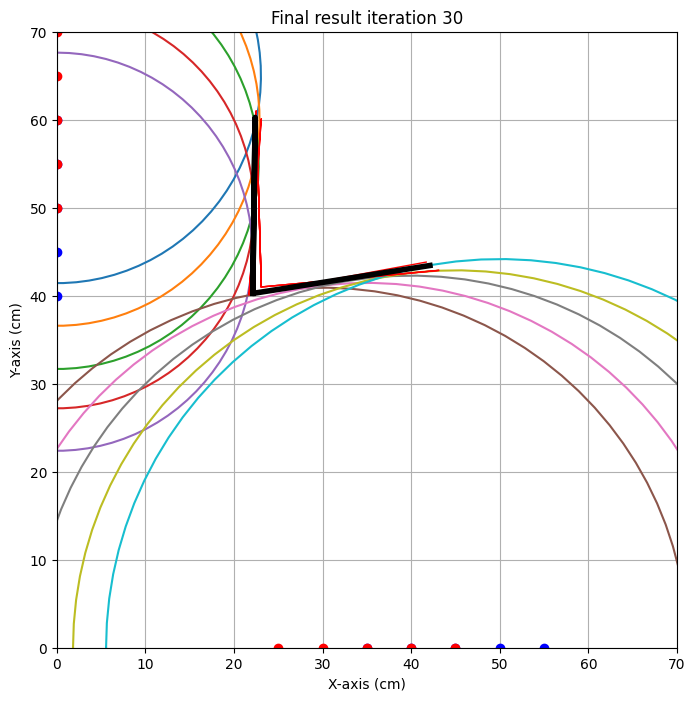

{'alpha': np.float64(9.011370991427984), 'alpha_eps': np.float64(3.642692596176639), 'beta': np.float64(0.7704435509050669), 'beta_eps': np.float64(3.16453754953395), 'x0': np.float64(22.115197679832843), 'x0_eps': np.float64(0.9647532539686381), 'y0': np.float64(40.262496148961716), 'y0_eps': np.float64(0.7327672883899368)}
test locatie 
x0 target is : 22.2. Gevonden waarde: 22.1 cm met een standaardafwijking van 1.0 cm 
y0 target is : 40.4. Gevonden waarde: 40.3 cm met een standaardafwijking van 0.7 cm 
alpha target is : 8.5. Gevonden waarde: 9.0 graden met een standaardafwijking van 3.6 graad 
beta target is : 4.0. Gevonden waarde: 0.8 graden met een standaardafwijking van 3.2 graad 



In [10]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  22.2,
                    'y0':  40.4,
                    'alpha' :  8.5,
                    'beta' :  4
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [0,70,0,60,47.15],
                    [0,65,0,55,46.84],
                    [0,60,0,50,46.66],
                    [0,55,0,45,45.60],
                    [0,50,0,40,45.25],
                    #[0,45,0,35,ongeldig]
                    [25,0,35,0,82.44],
                    [30,0,40,0,83.52],
                    [35,0,45,0,85.16],
                    [40,0,50,0,86.36],
                    [45,0,55,0,88.9]
                    #[50,0,60,0,ongeldig]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
## Stap 1:

<img src="Algoritme.jpeg" width="400">
<img src="algoritmechristoph.jpeg" width="400">
<img src="algorcasper.jpeg" width="400">

Dit zijn de drie algoritmes van ons alledrie.

## Stap 2:

<img src="iteratie1.jpeg" width="400">


Het algoritme van Christoph had te veel metingen dus de stapgrootte hebben we vergroot.

## Stap 3
<img src="iteratiefinal.jpeg" width="400">

We hebben twee algoritmes samengevoegd tot één algoritme, dit was het uiteindelijke algoritme. Het haalde de volgende waarden:

<img src="finaldata.png" width="400">